In [ ]:
import glob
import re
import polars as pl

# Columns like bid_price_5, ask_qty_12, etc. at levels 3..16 will be hidden
_SKIP_RE = re.compile(r'^(bid_price|ask_price|bid_qty|ask_qty)_(\d+)$')

def build_tokens(columns):
    """Return a token list where each element is ('col', idx) or ('skip',)."""
    tokens = []
    prev_skipped = False
    for i, col in enumerate(columns):
        m = _SKIP_RE.match(col)
        skip = bool(m) and 4 <= int(m.group(2)) <= 16
        if skip:
            if not prev_skipped:
                tokens.append(('skip', None))
            prev_skipped = True
        else:
            tokens.append(('col', i))
            prev_skipped = False
    return tokens

def print_schema(df, tokens):
    parts = []
    schema = df.schema
    cols = df.columns
    for kind, idx in tokens:
        if kind == 'col':
            parts.append(f"'{cols[idx]}': {schema[cols[idx]]}")
        else:
            parts.append("......")
    print("Schema:", "{" + ", ".join(parts) + "}", "Shape:", df.shape)

def print_row(row, tokens):
    parts = []
    for kind, idx in tokens:
        if kind == 'col':
            parts.append(repr(row[idx]))
        else:
            parts.append("......")
    print("(" + ", ".join(parts) + ")")

# Find all parquet files in the folder using a wildcard
file_paths = glob.glob("/kaggle/input/datasets/polylam1994/eth-amm/*.parquet")

# Loop through each file path dynamically
for path in sorted(file_paths):
    print(f"\n{'='*50}\nProcessing file: {path.split('/')[-1]}\n{'='*50}")

    # Read and inspect the dataset
    df = pl.read_parquet(path)
    tokens = build_tokens(df.columns)

    print_schema(df, tokens)

    print("\n--- Head (3) ---")
    for row in df.head(3).iter_rows():
        print_row(row, tokens)

    print("\n--- Tail (3) ---")
    for row in df.tail(3).iter_rows():
        print_row(row, tokens)


PART A CONFIGURATION (sanity-check simulation)
  run_sanity_simulation         : True
  simulations_per_set           : 10000
  progress_interval             : 5000
  poisson_A                     : 100.0
  poisson_k                     : 1.5
  initial_price                 : 100.0
  drift                         : 0.0
  volatility                    : 0.6
  dt                            : 0.01
  end_time                      : 10
  sigma                         : 0.6
  T                             : 10
  k                             : 1.5
  initial_cash                  : 10000.0
  initial_inventory             : 0
  gamma_sets                    : [{'gamma': 0.001, 'base_seed': 1}, {'gamma': 0.01, 'base_seed': 2}, {'gamma': 0.1, 'base_seed': 3}]


PART B CONFIGURATION (ETH perpetual backtest)
  run_eth_backtest                : True
  eth_data_dir                    : /kaggle/input/datasets/polylam1994/eth-amm/
  eth_dates                       : ['2026-03-19', '2026-03-20', '2026

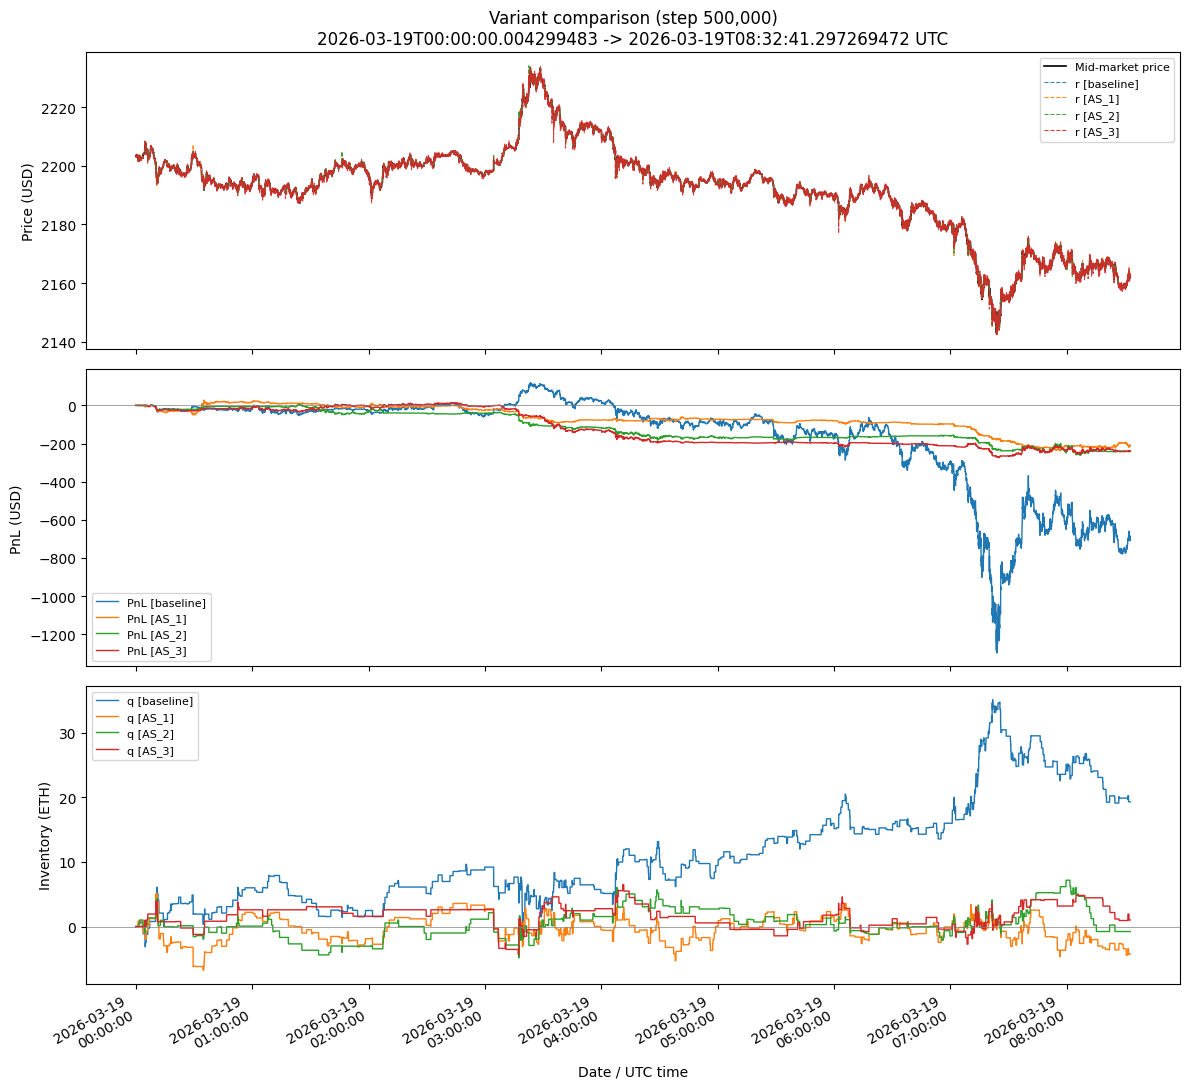


|  RUNNING STATISTICS  @ LOB step 500,000
|  LOB ts = 2026-03-19T08:32:41.815007015   mid = 2162.35 USD
|  funding f = -1.782e-04  ->  APR = f*3*365 = -19.52%   frac_since_8h_snapshot = 0.0681
|  EWMA sigma = 0.2436 price/sqrt(s)  (seed 0.35, 29,515 buckets, ON)
|  EWMA k = 13.7226  (seed 15.0, 9,394 trades, ON)
|  OFI drift mu = -1.277919e-02 USD/s  (beta=+1.946864e-03 [seed 0.001], bucket=1.0s, lambda=0.3, 29,515 buckets, 49 calibs on 1800 buckets)
|  mid realized vol (per-min log-rets, annualized *sqrt(525600)) = 62.37%
|  history samples = 50,000 (recorded every 10 events)

--- [baseline] Baseline (symmetric mid, AS spread) ---
  (0) POSITION SNAPSHOT
      formula : cash (USD) ; inventory q (ETH) ; inventory_market_value = q * mid
      period  : instantaneous, as of this LOB step
      value   : cash=957,515.44 USD  inventory=+19.326 ETH  inv_mkt_value=+41,789.58 USD
  (a) TOTAL PnL
      formula : PnL = equity - initial_cash ; equity = cash + q*mid + funding_accrued
      perio

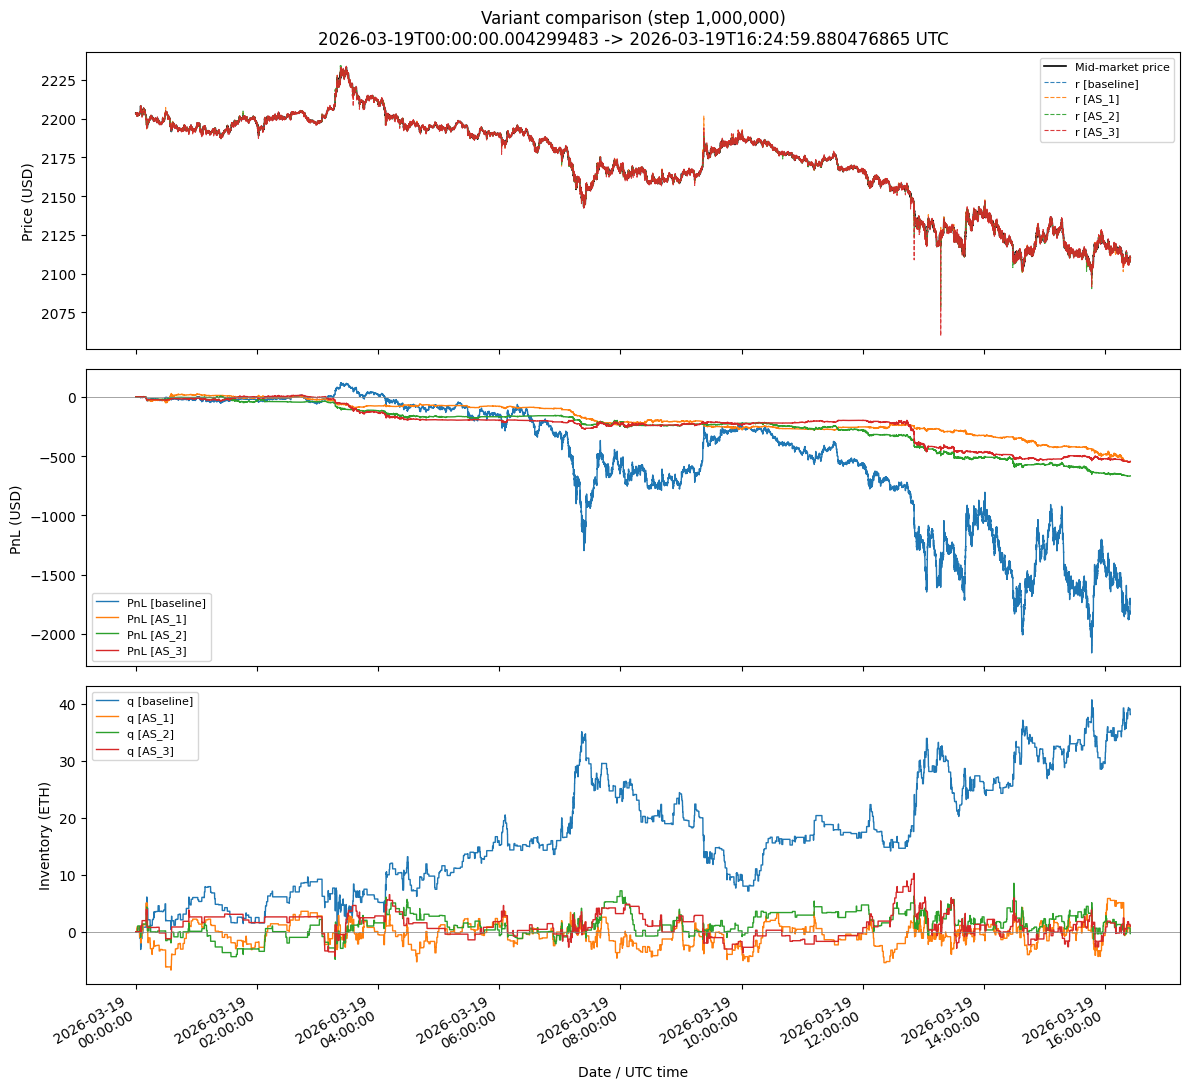


|  RUNNING STATISTICS  @ LOB step 1,000,000
|  LOB ts = 2026-03-19T16:25:00.337673699   mid = 2110.05 USD
|  funding f = +2.130e-05  ->  APR = f*3*365 = +2.33%   frac_since_8h_snapshot = 0.0521
|  EWMA sigma = 0.2635 price/sqrt(s)  (seed 0.35, 56,916 buckets, ON)
|  EWMA k = 9.9247  (seed 15.0, 21,796 trades, ON)
|  OFI drift mu = -7.356448e-02 USD/s  (beta=+2.724650e-03 [seed 0.001], bucket=1.0s, lambda=0.3, 56,916 buckets, 99 calibs on 1800 buckets)
|  mid realized vol (per-min log-rets, annualized *sqrt(525600)) = 72.52%
|  history samples = 100,000 (recorded every 10 events)

--- [baseline] Baseline (symmetric mid, AS spread) ---
  (0) POSITION SNAPSHOT
      formula : cash (USD) ; inventory q (ETH) ; inventory_market_value = q * mid
      period  : instantaneous, as of this LOB step
      value   : cash=917,799.58 USD  inventory=+38.131 ETH  inv_mkt_value=+80,458.32 USD
  (a) TOTAL PnL
      formula : PnL = equity - initial_cash ; equity = cash + q*mid + funding_accrued
      per

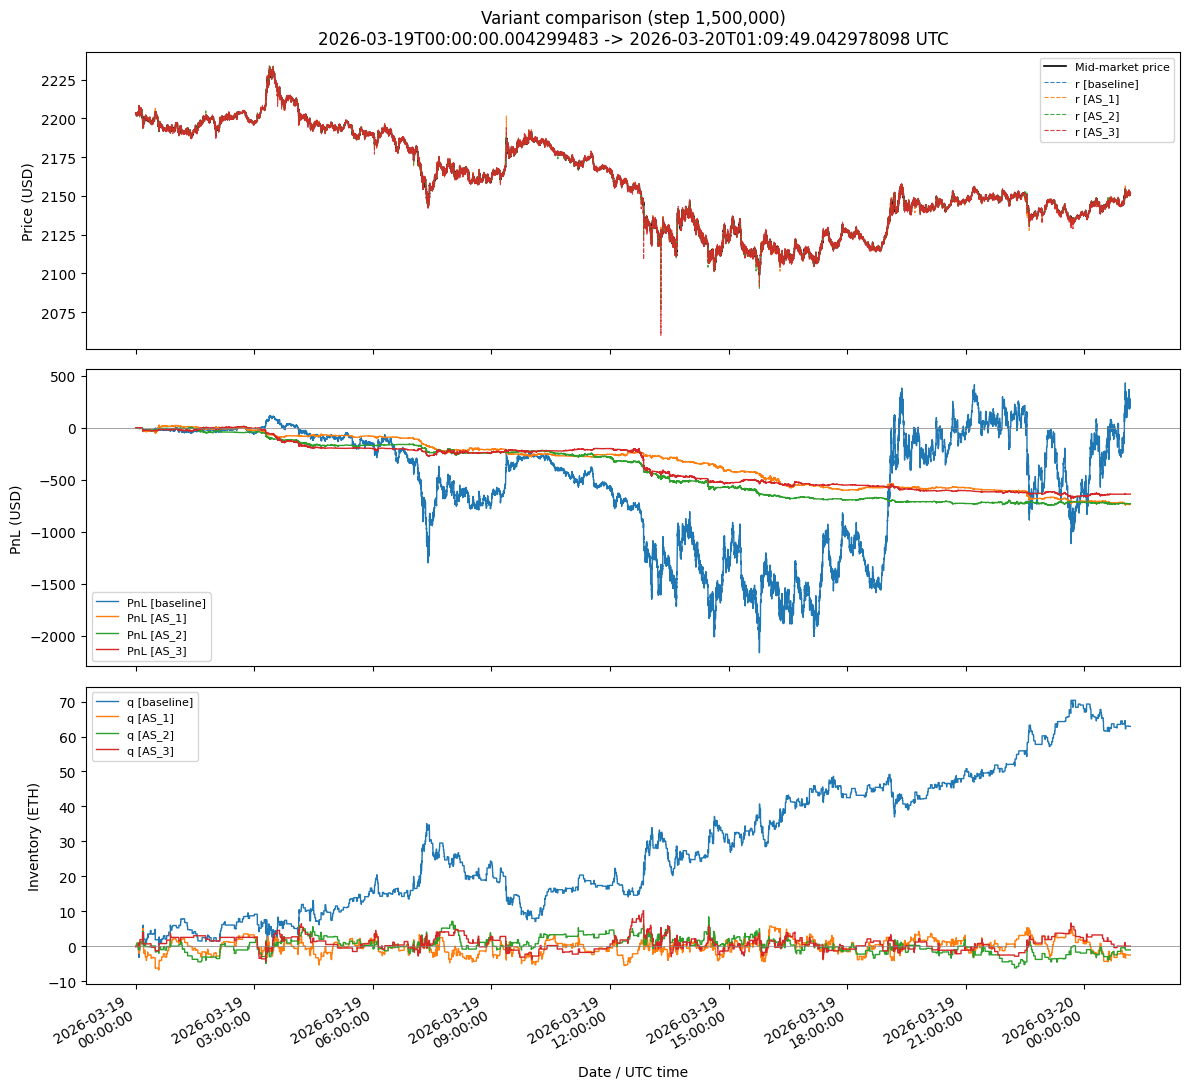


|  RUNNING STATISTICS  @ LOB step 1,500,000
|  LOB ts = 2026-03-20T01:09:49.543984206   mid = 2151.55 USD
|  funding f = +1.977e-05  ->  APR = f*3*365 = +2.16%   frac_since_8h_snapshot = 0.1455
|  EWMA sigma = 0.0766 price/sqrt(s)  (seed 0.35, 87,082 buckets, ON)
|  EWMA k = 13.3298  (seed 15.0, 30,278 trades, ON)
|  OFI drift mu = +1.754546e-02 USD/s  (beta=+2.065567e-03 [seed 0.001], bucket=1.0s, lambda=0.3, 87,082 buckets, 149 calibs on 1800 buckets)
|  mid realized vol (per-min log-rets, annualized *sqrt(525600)) = 69.33%
|  history samples = 150,000 (recorded every 10 events)

--- [baseline] Baseline (symmetric mid, AS spread) ---
  (0) POSITION SNAPSHOT
      formula : cash (USD) ; inventory q (ETH) ; inventory_market_value = q * mid
      period  : instantaneous, as of this LOB step
      value   : cash=864,910.64 USD  inventory=+62.906 ETH  inv_mkt_value=+135,345.40 USD
  (a) TOTAL PnL
      formula : PnL = equity - initial_cash ; equity = cash + q*mid + funding_accrued
      

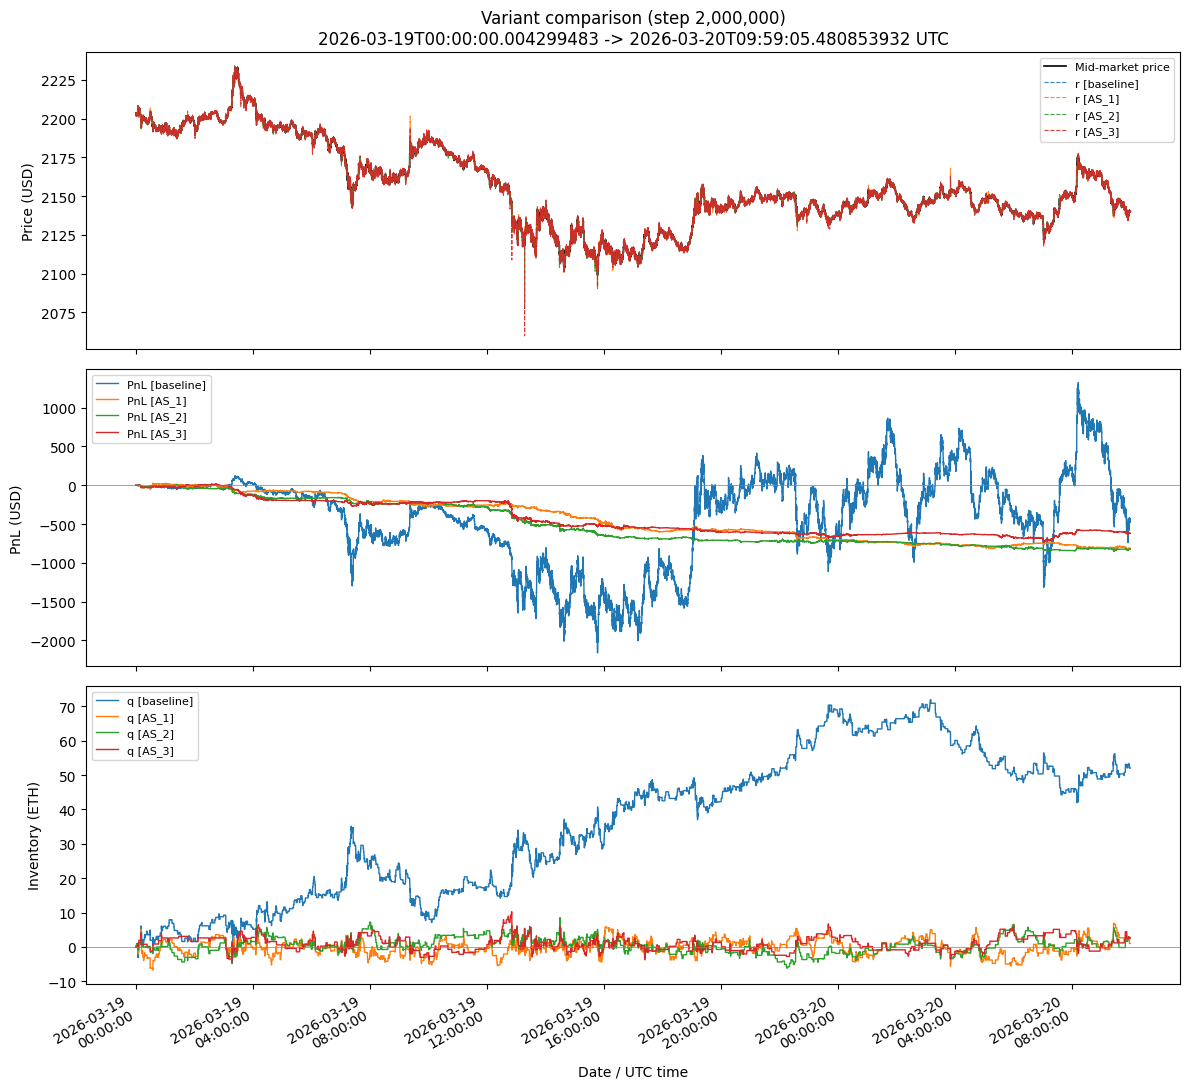


|  RUNNING STATISTICS  @ LOB step 2,000,000
|  LOB ts = 2026-03-20T09:59:05.960766210   mid = 2139.85 USD
|  funding f = -1.215e-04  ->  APR = f*3*365 = -13.30%   frac_since_8h_snapshot = 0.2481
|  EWMA sigma = 0.1621 price/sqrt(s)  (seed 0.35, 117,502 buckets, ON)
|  EWMA k = 9.4092  (seed 15.0, 37,258 trades, ON)
|  OFI drift mu = +1.792512e-02 USD/s  (beta=+1.989025e-03 [seed 0.001], bucket=1.0s, lambda=0.3, 117,502 buckets, 199 calibs on 1800 buckets)
|  mid realized vol (per-min log-rets, annualized *sqrt(525600)) = 65.51%
|  history samples = 200,000 (recorded every 10 events)

--- [baseline] Baseline (symmetric mid, AS spread) ---
  (0) POSITION SNAPSHOT
      formula : cash (USD) ; inventory q (ETH) ; inventory_market_value = q * mid
      period  : instantaneous, as of this LOB step
      value   : cash=888,197.20 USD  inventory=+52.029 ETH  inv_mkt_value=+111,334.26 USD
  (a) TOTAL PnL
      formula : PnL = equity - initial_cash ; equity = cash + q*mid + funding_accrued
    

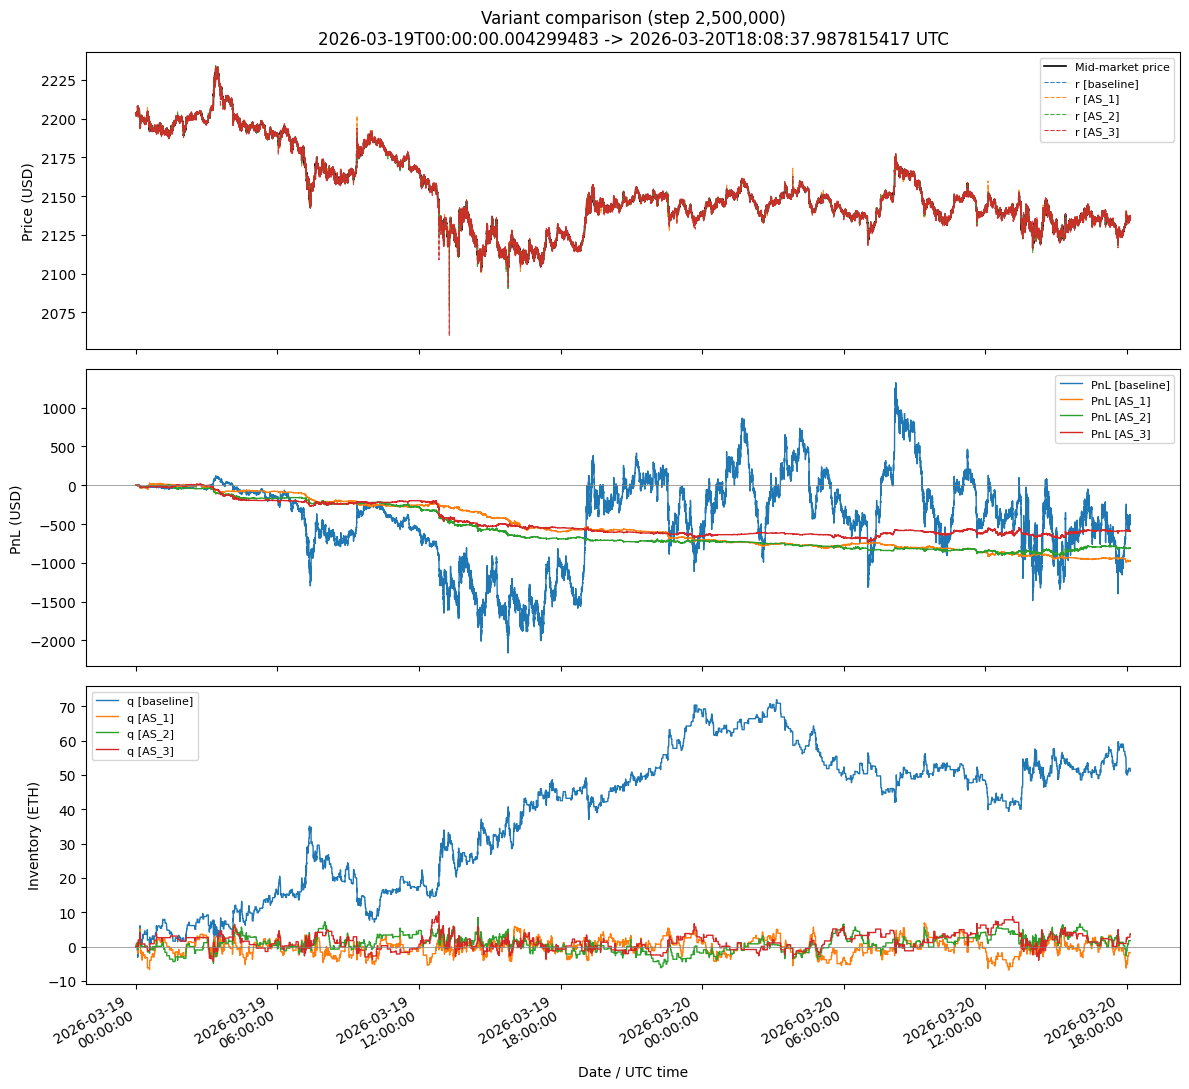


|  RUNNING STATISTICS  @ LOB step 2,500,000
|  LOB ts = 2026-03-20T18:08:38.705782202   mid = 2135.95 USD
|  funding f = -1.535e-04  ->  APR = f*3*365 = -16.81%   frac_since_8h_snapshot = 0.2680
|  EWMA sigma = 0.2255 price/sqrt(s)  (seed 0.35, 145,777 buckets, ON)
|  EWMA k = 11.2575  (seed 15.0, 46,911 trades, ON)
|  OFI drift mu = -1.067979e-01 USD/s  (beta=+2.000971e-03 [seed 0.001], bucket=1.0s, lambda=0.3, 145,777 buckets, 249 calibs on 1800 buckets)
|  mid realized vol (per-min log-rets, annualized *sqrt(525600)) = 67.13%
|  history samples = 250,000 (recorded every 10 events)

--- [baseline] Baseline (symmetric mid, AS spread) ---
  (0) POSITION SNAPSHOT
      formula : cash (USD) ; inventory q (ETH) ; inventory_market_value = q * mid
      period  : instantaneous, as of this LOB step
      value   : cash=890,300.99 USD  inventory=+51.149 ETH  inv_mkt_value=+109,251.71 USD
  (a) TOTAL PnL
      formula : PnL = equity - initial_cash ; equity = cash + q*mid + funding_accrued
   

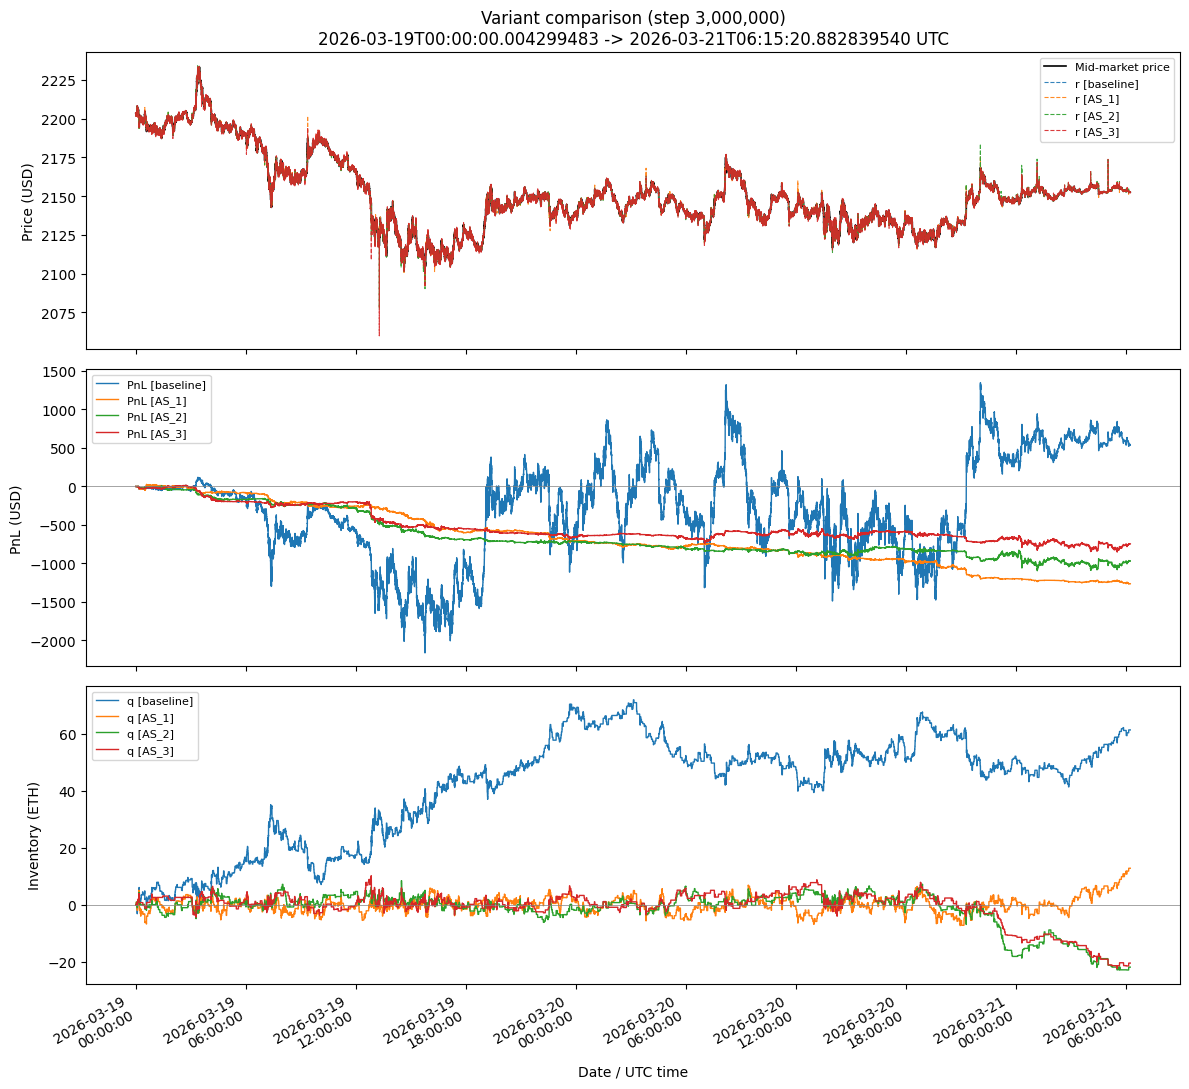


|  RUNNING STATISTICS  @ LOB step 3,000,000
|  LOB ts = 2026-03-21T06:15:21.827469193   mid = 2152.65 USD
|  funding f = +3.687e-05  ->  APR = f*3*365 = +4.04%   frac_since_8h_snapshot = 0.7820
|  EWMA sigma = 0.0067 price/sqrt(s)  (seed 0.35, 186,471 buckets, ON)
|  EWMA k = 7.0116  (seed 15.0, 56,791 trades, ON)
|  OFI drift mu = +1.514962e-03 USD/s  (beta=+9.418204e-04 [seed 0.001], bucket=1.0s, lambda=0.3, 186,471 buckets, 299 calibs on 1800 buckets)
|  mid realized vol (per-min log-rets, annualized *sqrt(525600)) = 62.24%
|  history samples = 300,000 (recorded every 10 events)

--- [baseline] Baseline (symmetric mid, AS spread) ---
  (0) POSITION SNAPSHOT
      formula : cash (USD) ; inventory q (ETH) ; inventory_market_value = q * mid
      period  : instantaneous, as of this LOB step
      value   : cash=868,485.97 USD  inventory=+61.347 ETH  inv_mkt_value=+132,058.62 USD
  (a) TOTAL PnL
      formula : PnL = equity - initial_cash ; equity = cash + q*mid + funding_accrued
     

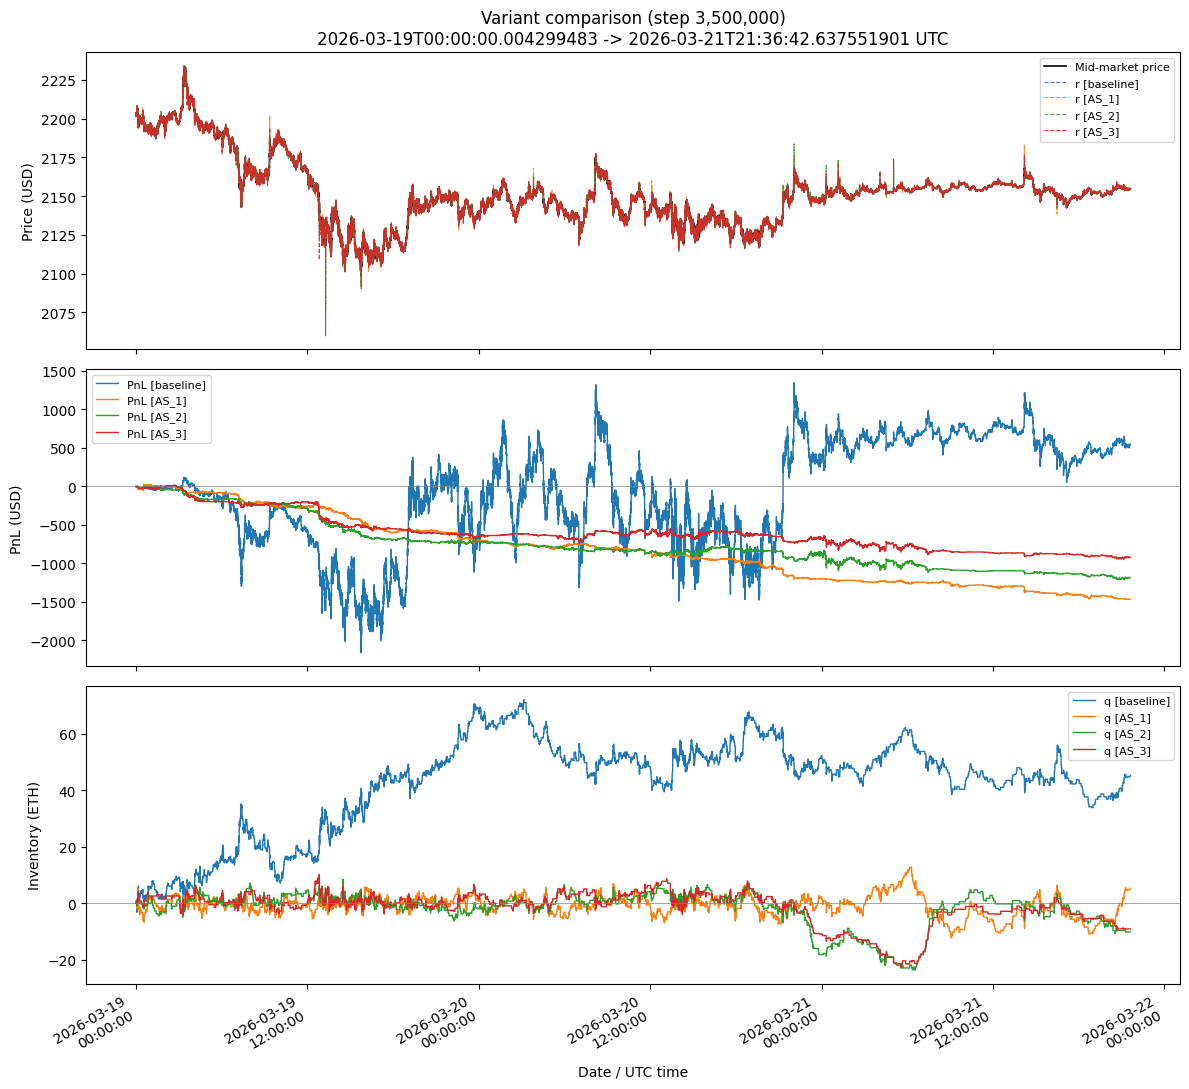


|  RUNNING STATISTICS  @ LOB step 3,500,000
|  LOB ts = 2026-03-21T21:36:43.636612685   mid = 2154.75 USD
|  funding f = +7.054e-05  ->  APR = f*3*365 = +7.72%   frac_since_8h_snapshot = 0.7015
|  EWMA sigma = 0.0000 price/sqrt(s)  (seed 0.35, 237,626 buckets, ON)
|  EWMA k = 19.1006  (seed 15.0, 66,575 trades, ON)
|  OFI drift mu = +6.956969e-03 USD/s  (beta=+1.379878e-03 [seed 0.001], bucket=1.0s, lambda=0.3, 237,626 buckets, 349 calibs on 1800 buckets)
|  mid realized vol (per-min log-rets, annualized *sqrt(525600)) = 55.99%
|  history samples = 350,000 (recorded every 10 events)

--- [baseline] Baseline (symmetric mid, AS spread) ---
  (0) POSITION SNAPSHOT
      formula : cash (USD) ; inventory q (ETH) ; inventory_market_value = q * mid
      period  : instantaneous, as of this LOB step
      value   : cash=903,178.73 USD  inventory=+45.187 ETH  inv_mkt_value=+97,366.69 USD
  (a) TOTAL PnL
      formula : PnL = equity - initial_cash ; equity = cash + q*mid + funding_accrued
     

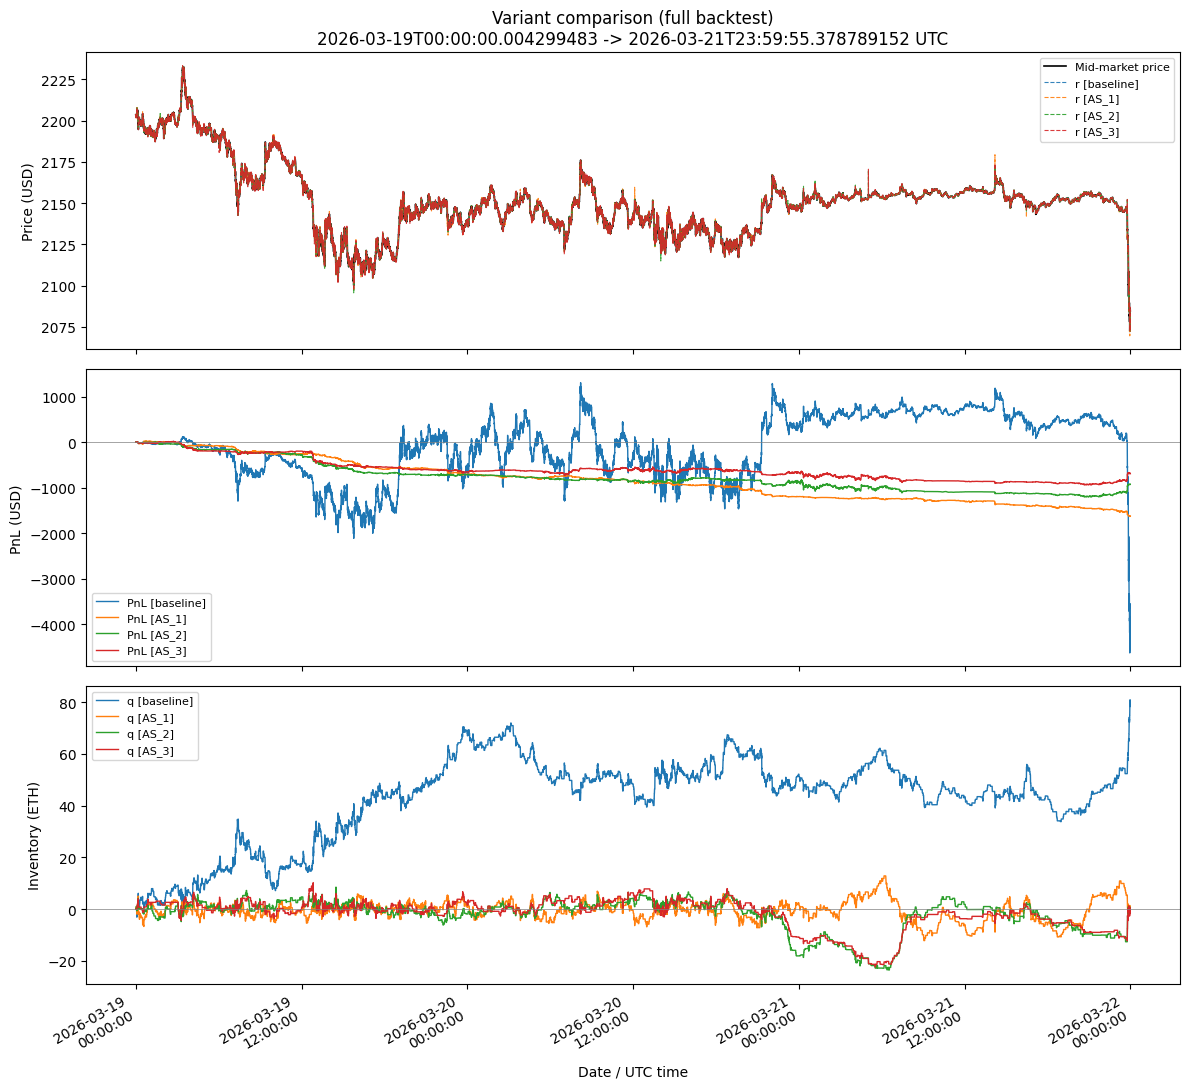

In [28]:
import math
import random
import time as time_module
from abc import ABC, abstractmethod
from collections import deque
from dataclasses import dataclass, field
from typing import List, Optional

import numpy as np
import polars as pl

try:
    import matplotlib.pyplot as plt
except ImportError:          # plotting is optional
    plt = None

# ============================================================================
# |                            CONFIGURATION                                 |
# ============================================================================

CONFIG = {
    # ======================================================================
    # PART A : sanity-check simulation (now built on the Part B quoter)
    # ======================================================================
    "run_sanity_simulation": True,
    "simulations_per_set": 10000,        
    "progress_interval": 5000,
    "poisson_A": 100.0,
    "poisson_k": 1.5,
    "initial_price": 100.0,
    "drift": 0.0,
    "volatility": 0.6,
    "dt": 0.01,
    "end_time": 10,
    "sigma": 0.6,
    # AS terminal horizon. Must cover the FULL simulation horizon
    # (T == end_time) so that tau = (T - t) stays non-negative over the whole
    # path; a negative tau would invert the inventory skew.
    "T": 10,
    "k": 1.5,
    "initial_cash": 10000.0,
    "initial_inventory": 0,
    "gamma_sets": [
        {"gamma": 0.001, "base_seed": 1},
        {"gamma": 0.01,  "base_seed": 2},
        {"gamma": 0.1,   "base_seed": 3},
    ],

    # ======================================================================
    # PART B : ETH perpetual backtest
    # ======================================================================
    "run_eth_backtest": True,
    "eth_data_dir": "/kaggle/input/datasets/polylam1994/eth-amm/",
    "eth_dates": ["2026-03-19", "2026-03-20", "2026-03-21"],

    # --- instrument / sizing (Change 1: 3-decimal order sizes) -----------
    "eth_tick_size": 0.1,
    "eth_size_decimals": 3,           # ETH perp size granularity
    "eth_order_size": 1,            # quoted size per side (ETH)
    "eth_min_order_size": 0.001,
    "eth_max_inventory": 100.0,         # hard |q| cap (ETH)
    "eth_initial_cash": 1000000.0,     # USD

    # --- AS-with-tau quoting (Change 2) -----------------------------------
    "eth_gamma": 0.2,               # risk aversion
    "eth_sigma": 0.35,                # SEED / fallback sigma (price units per
                                      # sqrt(SECOND)); now only used until the
                                      # EWMA estimator (Change 8) warms up.
    "eth_k": 15.0,                    # SEED / fallback order-arrival intensity
                                      # decay; now only used until the EWMA k
                                      # estimator (Change 10) warms up.
    "eth_tau": 5.0,                 # inventory-recycling constant (SECONDS)

    # --- realized-vol EWMA sigma (Change 8: fix hardcoded eth_sigma) ------
    # Sigma is estimated online instead of asserted. The mid is sampled on
    # fixed `bucket_s`-second buckets; the per-bucket mid change dS feeds an
    # EWMA of dS^2, and sigma = sqrt(EWMA[dS^2] / bucket_s) so sigma^2 is a
    # variance per SECOND (same units as the old constant). Forward-only, no
    # look-ahead; the seed eth_sigma is used until `min_buckets` have closed.
    "eth_sigma_ewma_on": True,
    "eth_sigma_bucket_s": 1.0,        # mid sampling bucket for dS
    "eth_sigma_ewma_lambda": 0.2,    # EWMA weight on the newest dS^2 bucket
                                      # (~1/lambda buckets of memory)
    "eth_sigma_min_buckets": 300,     # buckets before trusting the estimate

    # --- realized order-arrival intensity k (Change 10: fix hardcoded eth_k)
    # k is the AS intensity decay in lambda(delta)=A*exp(-k*delta). It is
    # estimated online from public trades: the distance a market order reaches
    # from the mid, delta=|trade_price - mid|, is ~Exponential(k), so its
    # maximum-likelihood estimator is k = 1/E[delta]. E[delta] is tracked with
    # an EWMA over successive trades; forward-only (each trade uses the most
    # recent observed mid), no look-ahead. The seed eth_k is used until
    # `min_trades` trades have been seen, then the live estimate (clamped to
    # [k_min, k_max]) is used. k feeds the AS base spread via
    # (2/gamma)*log(1+gamma/k), so the spread tracks live liquidity.
    "eth_k_ewma_on": True,
    "eth_k_ewma_lambda": 0.02,        # EWMA weight on the newest trade distance
                                      # (~1/lambda trades of memory)
    "eth_k_min_trades": 500,          # trades before trusting the estimate
    "eth_k_min": 0.5,                 # clamp: floor on k (caps the spread blow-up)
    "eth_k_max": 500.0,               # clamp: ceiling on k

    # --- funding (Changes 3 & 4) ------------------------------------------
    "eth_funding_accounting_on": True,   # Change 3: snapshot funding PnL
                                         # (applies to ALL variants: accounting)
    "eth_funding_skew_on": False,         # Change 4: funding skew in r
                                         # (PARTIAL variant only; full=ON,
                                         #  baseline=OFF regardless)
    "eth_funding_period_s": 8 * 3600,    # 8h between UTC snapshots

    # --- transaction-cost skew (Change 5) ----------------------------------
    "eth_tc_rate": 0.0001,            # maker fee rate on notional (1 bp)
                                      # (fee is charged to ALL variants)
    "eth_tc_skew_on": False,           # PARTIAL variant only; full=ON,
                                      # baseline=OFF regardless
    "eth_tc_skew_mult": 1.0,          # skew = mid * tc_rate * mult per side

    # --- markout / adverse-selection diagnostic (Change 9) -----------------
    "eth_markout_horizons_s": [1.0, 3.0, 5.0, 10.0],

    # --- OFI drift term (Change 7; 4th variant "AS_3" ONLY) ----------
    # mu_t = beta * OFI_bucket / bucket_s (price units per SECOND), then
    # EWMA-smoothed across successive buckets, then applied to the reservation
    # price as drift_skew = mu * horizon (bid & ask shifted up when mu > 0).
    "eth_drift_beta": 0.001,          # price-impact coefficient: USD price move
                                     # per unit OFI over one bucket. Used as-is
                                     # when calibration is OFF; used as the SEED
                                     # value until the first calibration fires
                                     # when calibration is ON.
    "eth_drift_bucket_s": 1.0,       # OFI aggregation bucket -> ONE mu step
                                     # (~a handful of L1 events per bucket).
    "eth_drift_ewma_lambda": 0.3,    # EWMA weight on the newest mu bucket
                                     # (damps single-bucket noise).
    "eth_drift_max_skew_usd": 1,   # safety clamp on |drift_skew| (USD) so the
                                     # drift term can never dominate the quotes.

    # --- OFI beta auto-calibration (Change 7, optional) --------------------
    # When ON, beta is re-estimated online by OLS-through-origin of the
    # per-bucket mid change on the per-bucket OFI:
    #     beta_hat = sum(OFI_k * dMid_k) / sum(OFI_k^2)
    # over a rolling window of the most recent `calibrate_window` buckets,
    # recomputed every `calibrate_every` LOB events. No look-ahead: only
    # already-closed buckets (ts <= now) enter the regression.
    "eth_drift_calibrate_beta": True,      # master switch (Calibration_Beta)
    "eth_drift_calibrate_every": 10000,   # LOB steps between recalibrations.
                                           
    "eth_drift_calibrate_window": 1800,    # rolling buckets in the OLS fit
                                           
    "eth_drift_calibrate_min_samples": 600,  # min buckets before the FIRST
                                             # calibration fires (else keep seed
                                             # beta).

    # --- strategy variants run side by side --------------------------------
    "eth_variants": {                 # enable/disable each variant
        "baseline": True,             # symmetric mid quote (q forced to 0)
        "AS_1": True,              # AS + skews per the config flags above
        "AS_2": True,                 # AS + funding skew ON + tc skew ON
        "AS_3": True,           # full AS + OFI drift term (Change 7)
    },

    # --- queue / execution model (Change 6) --------------------------------
    "eth_queue_shrink_with_book": True,  # queue_ahead <= displayed qty heuristic
    "eth_requote_tolerance_ticks": 3,    # keep order (and queue pos) if desired
                                         # price within this many ticks

    # --- engine / reporting -------------------------------------------------
    "eth_print_every": 500_000,       # print analytics every x LOB events
    "eth_stats_every": 500_000,       # print practitioner RUNNING STATISTICS
                                      # every x LOB events (formulas + period
                                      # printed inline)
    "eth_plot_on_print": True,        # comparison plot at each printing
    "eth_plot_window": 500_000,         # recorded points shown in each plot
    "eth_plot_final": True,           # full-history comparison plot in report
    "eth_plot_max_points": 20_000,    # downsample cap for the final plot
    "eth_record_every": 10,           # record history every N events (memory)
    "eth_max_events_per_day": None,   # int for quick debugging, None = all
}

# ============================================================================
# |                       CONFIGURATION PRINTERS                             |
# ============================================================================


def print_part_a_config() -> None:
    """Print the full Part A (sanity-check simulation) configuration."""
    print("\n" + "=" * 60)
    print("PART A CONFIGURATION (sanity-check simulation)")
    print("=" * 60)
    keys_a = [
        "run_sanity_simulation", "simulations_per_set", "progress_interval",
        "poisson_A", "poisson_k", "initial_price", "drift", "volatility",
        "dt", "end_time", "sigma", "T", "k", "initial_cash",
        "initial_inventory", "gamma_sets",
    ]
    for kk in keys_a:
        print(f"  {kk:30s}: {CONFIG[kk]}")
    print("=" * 60 + "\n")


def print_part_b_config() -> None:
    """Print the full Part B (ETH perpetual backtest) configuration."""
    print("\n" + "=" * 60)
    print("PART B CONFIGURATION (ETH perpetual backtest)")
    print("=" * 60)
    keys_b = [
        "run_eth_backtest", "eth_data_dir", "eth_dates",
        "eth_tick_size", "eth_size_decimals", "eth_order_size",
        "eth_min_order_size", "eth_max_inventory", "eth_initial_cash",
        "eth_gamma", "eth_sigma", "eth_k", "eth_tau",
        "eth_sigma_ewma_on", "eth_sigma_bucket_s", "eth_sigma_ewma_lambda",
        "eth_sigma_min_buckets",
        "eth_k_ewma_on", "eth_k_ewma_lambda", "eth_k_min_trades",
        "eth_k_min", "eth_k_max",
        "eth_funding_accounting_on", "eth_funding_skew_on",
        "eth_funding_period_s",
        "eth_tc_rate", "eth_tc_skew_on", "eth_tc_skew_mult",
        "eth_markout_horizons_s",
        "eth_drift_beta", "eth_drift_bucket_s", "eth_drift_ewma_lambda",
        "eth_drift_max_skew_usd",
        "eth_drift_calibrate_beta", "eth_drift_calibrate_every",
        "eth_drift_calibrate_window", "eth_drift_calibrate_min_samples",
        "eth_variants",
        "eth_queue_shrink_with_book", "eth_requote_tolerance_ticks",
        "eth_print_every", "eth_stats_every", "eth_plot_on_print",
        "eth_plot_window", "eth_plot_final", "eth_plot_max_points",
        "eth_record_every", "eth_max_events_per_day",
    ]
    for kk in keys_b:
        print(f"  {kk:32s}: {CONFIG[kk]}")
    print("=" * 60 + "\n")

# ============================================================================
# ============================================================================
# ||       PART A : SANITY-CHECK SIMULATION (special case of Part B)        ||
# ============================================================================
# ============================================================================

# ----------------------------- core/tick.hpp -------------------------------

@dataclass
class Tick:
    """A market data tick: timestamp and instrument price."""
    time: float = 0.0
    price: float = 0.0

# ----------------------------- core/quote.hpp ------------------------------

@dataclass
class Quote:
    """A market-maker quote on a trading instrument."""
    mid: float = 0.0
    bid: float = 0.0
    ask: float = 0.0
    delta: float = 0.0   # half spread

# --------------------------- core/book_state.hpp ---------------------------

@dataclass
class BookState:
    """State of the market-maker book at a given time."""
    time: float = 0.0
    stocks_sold: int = 0
    stocks_bought: int = 0
    inventory: int = 0
    cash: float = 0.0

# ------------------------- core/book_snapshot.hpp --------------------------

@dataclass
class BookSnapshot:
    """Snapshot of the market-maker's situation at a specific time."""
    tick: Tick
    state: BookState
    quote: Quote

# ------------------------ core/trading_history.hpp -------------------------

@dataclass
class TradingHistory:
    """History of the market-maker's books and quotes over a trading period."""
    snapshots: List[BookSnapshot] = field(default_factory=list)

    def add_snapshot(self, snapshot: BookSnapshot) -> None:
        self.snapshots.append(snapshot)

# --------------------- market/i_market_data_stream.hpp ---------------------

class IMarketDataStream(ABC):
    """Abstract base class for market data streams."""

    @abstractmethod
    def next_tick(self) -> Tick: ...

    @abstractmethod
    def has_next(self) -> bool: ...

    @abstractmethod
    def reset(self) -> None: ...

# ------------------------ market/brownian_stream.cpp -----------------------

class BrownianStream(IMarketDataStream):
    """Generates market data following a ABM."""

    def __init__(self, initial_price: float, dt: float, drift: float,
                 volatility: float, end_time: float, seed: int = 42):
        if dt <= 0.0:
            raise ValueError("BrownianStream: dt must be > 0")
        if volatility < 0.0:
            raise ValueError("BrownianStream: volatility must be >= 0")
        if end_time < 0.0:
            raise ValueError("BrownianStream: end_time must be >= 0")

        self._initial_price = initial_price
        self._dt = dt
        self._drift = drift
        self._volatility = volatility
        self._end_time = end_time
        self._rng = random.Random(seed)

        self._current_time = 0.0
        self._current_price = initial_price
        self._stream: List[Tick] = [Tick(self._current_time, self._current_price)]

    def next_tick(self) -> Tick:
        if not self.has_next():
            raise IndexError("BrownianStream.next_tick: reached end_time")
        z = self._rng.gauss(0.0, 1.0)
        dW = math.sqrt(self._dt) * z
        self._current_time += self._dt
        drift_term = (self._drift - 0.5 * self._volatility ** 2) * self._dt
        diffusion_term = self._volatility * dW
        self._current_price += self._drift * self._dt + self._volatility * dW
        tick = Tick(self._current_time, self._current_price)
        self._stream.append(tick)
        return tick

    def has_next(self) -> bool:
        return (self._current_time + self._dt) <= self._end_time

    def reset(self) -> None:
        self._current_time = 0.0
        self._current_price = self._initial_price
        self._stream = [Tick(self._current_time, self._current_price)]

    def stream(self) -> List[Tick]:
        return list(self._stream)

    def size(self) -> int:
        return len(self._stream)

    def clear_stream(self) -> None:
        self._stream = []

# -------------------------- market/csv_stream.cpp --------------------------

class CSVStream(IMarketDataStream):
    """Reads historical tick data (time, price rows) from a CSV file."""

    def __init__(self, filepath: str):
        self._filepath = filepath
        self._ticks: List[Tick] = []
        self._current_index = 0
        self.load_data()

    def load_data(self) -> None:
        self._ticks = []
        self._current_index = 0
        try:
            file = open(self._filepath, "r")
        except OSError:
            raise RuntimeError(
                f"CSVStream.load_data: failed to open file: {self._filepath}")
        with file:
            for line in file:
                line = line.strip()
                if not line:
                    continue
                parts = line.split(",", 1)
                if len(parts) < 2:
                    continue
                try:
                    self._ticks.append(Tick(float(parts[0]), float(parts[1])))
                except ValueError:
                    continue

    def next_tick(self) -> Tick:
        if not self.has_next():
            raise IndexError("CSVStream.next_tick: no more ticks available")
        tick = self._ticks[self._current_index]
        self._current_index += 1
        return tick

    def has_next(self) -> bool:
        return self._current_index < len(self._ticks)

    def reset(self) -> None:
        self._current_index = 0

    def size(self) -> int:
        return len(self._ticks)

# ------------------------- orders/i_inventory.hpp --------------------------

class IInventoryModel(ABC):
    """Interface for inventory models used in market making simulations."""

    @abstractmethod
    def update_inventory(self, current_inventory: int, delta: float) -> int: ...

# ----------------------- orders/poisson_inventory.cpp ----------------------

class PoissonSimulation(IInventoryModel):
    """Inventory movement simulated as a Poisson process.

    Part A FIX (dimensional consistency): A is an arrival INTENSITY (expected
    fills per unit TIME), so the expected number of fills over one tick of
    length dt is (A * dt) * exp(-k*delta), NOT A * exp(-k*delta). The previous
    code omitted dt and therefore inflated the realized arrival rate by 1/dt
    (a 100x overshoot at dt=0.01). We now scale the Poisson mean by dt so the
    fill counts (and hence the PnL scale) are dimensionally correct. The mean
    per tick is  lambda = A * dt * exp(-k*delta).
    """

    def __init__(self, A: float, k: float, seed: Optional[int] = None,
                 dt: float = 1.0):
        self._A = A
        self._k = k
        self._dt = dt
        self._rng = random.Random(seed)

    def _sample_poisson(self, lam: float) -> int:
        if lam <= 0.0:
            return 0
        L = math.exp(-lam)
        k = 0
        p = 1.0
        while True:
            p *= self._rng.random()
            if p <= L:
                return k
            k += 1

    def update_inventory(self, current_inventory: int, delta: float) -> int:
        # Clamp the exponent so math.exp cannot overflow when a quote is deep
        # through the mid (delta very negative); 700 is just below the float64
        # overflow threshold (~709). The intensity is scaled by dt so that
        # lambda is the expected number of fills over one tick (A is per unit
        # TIME), fixing the previous dimensional bug.
        lam = self._A * self._dt * math.exp(min(-self._k * delta, 700.0))
        return current_inventory + self._sample_poisson(lam)

# ------------------------- strategy/i_strategy.hpp -------------------------

class IStrategy(ABC):
    """Interface for market-making strategy implementations."""

    def __init__(self, initial_time: float = 0.0, initial_stocks_sold: int = 0,
                 initial_stocks_bought: int = 0, initial_inventory: int = 0,
                 initial_cash: float = 0.0):
        self._current_book = BookState(
            time=initial_time, stocks_sold=initial_stocks_sold,
            stocks_bought=initial_stocks_bought, inventory=initial_inventory,
            cash=initial_cash)
        self._last_quote: Optional[Quote] = None

    @abstractmethod
    def generate_quote(self, tick: Tick) -> Quote: ...

    def update_book(self, tick: Tick, new_stocks_sold: int,
                    new_stocks_bought: int) -> None:
        """Books sells at the last quoted ask and buys at the last quoted bid."""
        sold_fills = new_stocks_sold - self._current_book.stocks_sold
        bought_fills = new_stocks_bought - self._current_book.stocks_bought
        if self._last_quote is not None:
            sell_price, buy_price = self._last_quote.ask, self._last_quote.bid
        else:
            sell_price = buy_price = tick.price
        self._current_book = BookState(
            time=tick.time,
            stocks_sold=new_stocks_sold,
            stocks_bought=new_stocks_bought,
            inventory=new_stocks_bought - new_stocks_sold,
            cash=(self._current_book.cash
                  + sold_fills * sell_price - bought_fills * buy_price))

    def get_current_book(self) -> BookState:
        return self._current_book

# ------------------------- strategy/as_strategy.cpp ------------------------

class AsStrategy(IStrategy):
    """Avellaneda-Stoikov strategy, now expressed as a SPECIAL CASE of the
    Part B ETH quoter (`EthAsQuoter`), so the sanity check exercises the exact
    same quoting code path used by the ETH backtest.

    Special-casing (relative to the ETH backtest):
      * the fixed inventory-recycling constant tau is replaced by the original
        terminal-horizon countdown  tau := max(T - t, 0)  (Change 2 reversed;
        floored at zero so the skew can never flip sign past the horizon);
      * funding-aware skew         OFF;
      * transaction-cost skew       OFF;
      * OFI drift term              OFF.

    Baseline (`naive_mid=True`): quotes naively around the MID price instead of
    the indifference (reservation) price. Inventory is ignored when quoting
    (reservation collapses to mid), while the spread is identical. This is the
    benchmark that the AS indifference-price quoting is tested against.
    """

    def __init__(self, gamma: float, sigma: float, T: float, k: float,
                 initial_book: BookState, naive_mid: bool = False):
        super().__init__(initial_book.time, initial_book.stocks_sold,
                         initial_book.stocks_bought, initial_book.inventory,
                         initial_book.cash)
        self._gamma, self._sigma, self._T, self._k = gamma, sigma, T, k
        self._naive_mid = naive_mid

    def generate_quote(self, tick: Tick) -> Quote:
        # Change 2 reversed: tau := (T - t), floored at 0 so the reservation
        # skew cannot flip sign (and destabilize the inventory feedback) past
        # the terminal horizon.
        tau = max(self._T - tick.time, 0.0)
        # Construct the SAME quoter used by Part B, with all skews OFF (drift
        # off by default). tau is time-varying here, so the quoter (and its
        # spread) is built per tick.
        quoter = EthAsQuoter(gamma=self._gamma, sigma=self._sigma, k=self._k,
                             tau=tau, funding_skew_on=False, tc_skew_on=False,
                             tc_rate=0.0, tc_skew_mult=0.0)
        # Baseline ignores inventory in quoting -> reservation collapses to mid.
        q = 0.0 if self._naive_mid else self._current_book.inventory
        r, bid, ask = quoter.quote(mid=tick.price, q=q, funding_rate=0.0,
                                   frac_since_snapshot=0.0)
        delta = 0.5 * (ask - bid)
        quote = Quote(mid=r, bid=bid, ask=ask, delta=delta)
        self._last_quote = quote
        return quote

# -------------------------- strategy/benchmark.hpp -------------------------

class Benchmark(IStrategy):
    """Legacy benchmark strategy (superseded by AsStrategy(naive_mid=True));
    kept for reference. Not used by the Monte Carlo run."""

    def __init__(self, gamma: float, sigma: float, T: float, k: float):
        super().__init__()
        self._gamma, self._sigma, self._T, self._k = gamma, sigma, T, k

    def generate_quote(self, tick: Tick) -> Quote:
        mid = tick.price
        spread = (self._gamma * self._sigma ** 2 * (self._T - tick.time)
                  + (2.0 / self._gamma) * math.log(1.0 + self._gamma / self._k))
        delta = spread / 2.0
        quote = Quote(mid=mid, bid=mid - delta, ask=mid + delta, delta=delta)
        self._last_quote = quote
        return quote

# --------------------- simulations/market_simulator.cpp --------------------

class MarketSimulator:
    """Simulates market-making activity over a stream of market data.

    Fill intensities are driven by the PER-SIDE distance of each quote from
    the current mid price (delta_ask = ask - mid, delta_bid = mid - bid),
    i.e. lambda_side = A * exp(-k * delta_side), exactly as in the
    Avellaneda-Stoikov model. This is what lets the reservation-price skew
    asymmetrically modulate buy/sell fill intensities and produce the
    intended inventory mean-reversion.
    """

    def __init__(self, data_stream: IMarketDataStream, strategy: IStrategy,
                 order_sim_seed: Optional[int] = None):
        self._data_stream = data_stream
        self._strategy = strategy
        # Seeded so that the AS and the naive baseline share the SAME Poisson
        # fill randomness (fair, apples-to-apples comparison). The Poisson
        # intensity is scaled by dt inside PoissonSimulation (Part A fix), so
        # dt is forwarded here from CONFIG.
        self._order_sim: IInventoryModel = PoissonSimulation(
            CONFIG["poisson_A"], CONFIG["poisson_k"], seed=order_sim_seed,
            dt=CONFIG["dt"])

    def run(self) -> TradingHistory:
        history = TradingHistory()
        while self._data_stream.has_next():
            tick = self._data_stream.next_tick()
            quote = self._strategy.generate_quote(tick)
            book = self._strategy.get_current_book()
            # Per-side distances from the MID price drive the fill
            # intensities (AS model), not the half-spread.
            delta_ask = quote.ask - tick.price   # distance buyers must cross
            delta_bid = tick.price - quote.bid   # distance sellers must cross
            new_sold = self._order_sim.update_inventory(book.stocks_sold, delta_ask)
            new_bought = self._order_sim.update_inventory(book.stocks_bought, delta_bid)
            self._strategy.update_book(tick, new_sold, new_bought)
            history.add_snapshot(BookSnapshot(
                tick=tick, state=self._strategy.get_current_book(), quote=quote))
        return history

# -------------------- simulations/mc_parameter_set.hpp ---------------------

@dataclass
class MCParameterSet:
    initial_price: float = 100.0
    drift: float = 0.05
    volatility: float = 0.2
    dt: float = 0.01
    end_time: float = 10.0
    gamma: float = 0.01
    sigma: float = 0.2
    T: float = 1.0
    k: float = 1.5
    initial_cash: float = 10000.0
    initial_inventory: int = 0
    seeds: List[int] = field(default_factory=list)

# -------------------- simulations/simulation_result.hpp --------------------

@dataclass
class SimulationResult:
    final_pnl: float = 0.0
    mean_spread: float = 0.0
    final_inventory: int = 0
    initial_cash: float = 0.0
    final_cash: float = 0.0
    final_price: float = 0.0
    num_quotes: int = 0

# ------------------------ simulations/mc_stats.hpp -------------------------

@dataclass
class MCStats:
    mean_pnl: float = 0.0
    std_pnl: float = 0.0
    mean_final_inventory: float = 0.0
    std_final_inventory: float = 0.0
    mean_spread: float = 0.0
    sharpe_ratio: float = 0.0
    num_simulations: int = 0
    params: MCParameterSet = field(default_factory=MCParameterSet)
    set_id: int = 0

# ------------------------ simulations/mc_engine.cpp ------------------------

class MCEngine:
    """Monte Carlo engine running multiple market simulations per parameter set.

    For every seed it runs BOTH the AS indifference-price strategy and the
    naive mid-price baseline, on the SAME ABM path and the SAME Poisson fill
    realization, and stores statistics for both.
    """

    def __init__(self, num_simulations: int):
        if num_simulations <= 0:
            raise ValueError("Number of simulations must be positive")
        self._num_simulations = num_simulations
        self._stats_results: List[MCStats] = []      # AS (indifference price)
        self._baseline_results: List[MCStats] = []    # naive mid-price baseline

    def run(self, param_sets: List[MCParameterSet]) -> None:
        self._stats_results = []
        self._baseline_results = []
        print(f"Running {len(param_sets)} parameter sets, "
              f"{self._num_simulations} simulations each "
              f"(AS + naive mid-price baseline)...")
        for set_id, params in enumerate(param_sets):
            print(f"\n=== Parameter Set {set_id + 1} / {len(param_sets)} ===")
            set_start = time_module.perf_counter()
            as_results: List[SimulationResult] = []
            base_results: List[SimulationResult] = []
            for run_id in range(self._num_simulations):
                if (run_id + 1) % CONFIG["progress_interval"] == 0:
                    print(f"  Simulation {run_id + 1} / {self._num_simulations}")
                # Same price path + same Poisson fills for both strategies.
                as_sim = self._create_simulator(params, run_id, naive_mid=False)
                as_results.append(self._extract_result(as_sim.run()))
                base_sim = self._create_simulator(params, run_id, naive_mid=True)
                base_results.append(self._extract_result(base_sim.run()))
            as_stats = self._compute_statistics_for_set(as_results, params, set_id)
            base_stats = self._compute_statistics_for_set(base_results, params, set_id)
            print(f"  AS       : Mean PnL = {as_stats.mean_pnl}, "
                  f"Sharpe = {as_stats.sharpe_ratio}")
            print(f"  Baseline : Mean PnL = {base_stats.mean_pnl}, "
                  f"Sharpe = {base_stats.sharpe_ratio}")
            self._stats_results.append(as_stats)
            self._baseline_results.append(base_stats)
            elapsed = time_module.perf_counter() - set_start
            print(f"  Run in {elapsed:.3f} s")

    def _create_simulator(self, params: MCParameterSet, run_id: int,
                          naive_mid: bool = False) -> MarketSimulator:
        stream = BrownianStream(params.initial_price, params.dt, params.drift,
                                params.volatility, params.end_time,
                                params.seeds[run_id])
        strategy = AsStrategy(params.gamma, params.sigma, params.T, params.k,
                              BookState(0.0, 0, 0, params.initial_inventory,
                                        params.initial_cash),
                              naive_mid=naive_mid)
        return MarketSimulator(stream, strategy,
                               order_sim_seed=params.seeds[run_id])

    def _extract_result(self, history: TradingHistory) -> SimulationResult:
        if not history.snapshots:
            raise RuntimeError("Cannot extract result from empty trading history")
        first, last = history.snapshots[0], history.snapshots[-1]
        result = SimulationResult()
        result.num_quotes = len(history.snapshots)
        result.initial_cash = first.state.cash
        result.final_cash = last.state.cash
        result.final_inventory = last.state.inventory
        result.final_price = last.tick.price
        final_value = result.final_cash + result.final_inventory * result.final_price
        result.final_pnl = final_value - result.initial_cash
        total_spread = sum(2.0 * s.quote.delta for s in history.snapshots)
        result.mean_spread = total_spread / result.num_quotes
        return result

    def _compute_statistics_for_set(self, simulations: List[SimulationResult],
                                    params: MCParameterSet,
                                    set_id: int) -> MCStats:
        n = len(simulations)
        stats = MCStats(num_simulations=n, params=params, set_id=set_id)
        stats.mean_pnl = sum(r.final_pnl for r in simulations) / n
        stats.mean_final_inventory = sum(r.final_inventory for r in simulations) / n
        stats.mean_spread = sum(r.mean_spread for r in simulations) / n
        ss_pnl = sum((r.final_pnl - stats.mean_pnl) ** 2 for r in simulations)
        ss_inv = sum((r.final_inventory - stats.mean_final_inventory) ** 2
                     for r in simulations)
        stats.std_pnl = math.sqrt(ss_pnl / (n - 1)) if n > 1 else 0.0
        stats.std_final_inventory = math.sqrt(ss_inv / (n - 1)) if n > 1 else 0.0
        stats.sharpe_ratio = (stats.mean_pnl / stats.std_pnl
                              if stats.std_pnl > 0.0 else 0.0)
        return stats

    def get_statistics(self, set_id: int) -> MCStats:
        if set_id >= len(self._stats_results):
            raise IndexError(f"Invalid parameter set ID: {set_id}")
        return self._stats_results[set_id]

    def get_stats_results(self) -> List[MCStats]:
        return list(self._stats_results)

    def get_baseline_results(self) -> List[MCStats]:
        return list(self._baseline_results)

    def clear_results(self) -> None:
        self._stats_results = []
        self._baseline_results = []

# ------------------------ simulations/visualizer.cpp -----------------------

class Visualizer:
    """Visualizes and exports trading simulation results (PART A)."""

    @staticmethod
    def print_summary(history: TradingHistory) -> None:
        if not history.snapshots:
            print("No data in history")
            return
        first, last = history.snapshots[0], history.snapshots[-1]
        initial_pnl = Visualizer._calculate_pnl(first.state, first.tick.price)
        final_pnl = Visualizer._calculate_pnl(last.state, last.tick.price)
        print("\n=== Simulation Summary ===")
        print(f"Number of snapshots: {len(history.snapshots)}")
        print(f"Time range: {first.tick.time} -> {last.tick.time}")
        print(f"\nInitial state:\n  Cash: ${first.state.cash:.2f}"
              f"\n  Inventory: {first.state.inventory}\n  PnL: ${initial_pnl:.2f}")
        print(f"\nFinal state:\n  Cash: ${last.state.cash:.2f}"
              f"\n  Inventory: {last.state.inventory}\n  PnL: ${final_pnl:.2f}")
        print(f"\nPerformance:\n  Total PnL change: ${final_pnl - initial_pnl:.2f}"
              f"\n  Inventory change: "
              f"{last.state.inventory - first.state.inventory}")
        print("==========================\n")

    @staticmethod
    def _calculate_pnl(state: BookState, price: float) -> float:
        return state.cash + state.inventory * price


def generate_seeds(n: int, base_seed: int = 42) -> List[int]:
    return [base_seed + i for i in range(n)]

def print_results_table(as_all: List[MCStats], base_all: List[MCStats]) -> None:
    """Print AS vs Baseline metrics as a table: metrics in rows, one
    column group per parameter set (gamma), AS / Base side by side,
    followed by an AS - Baseline difference table."""
    metrics = [
        ("Mean PnL",        lambda s: s.mean_pnl),
        ("Std PnL",         lambda s: s.std_pnl),
        ("Sharpe Ratio",    lambda s: s.sharpe_ratio),
        ("Mean Final Inv",  lambda s: s.mean_final_inventory),
        ("Std Final Inv",   lambda s: s.std_final_inventory),
        ("Mean Spread",     lambda s: s.mean_spread),
    ]
    WM, WC = 16, 10                      # metric-name width, cell width
    group_w = 2 * WC + 1                 # AS cell + space + Base cell

    header1 = " " * WM + " |"
    header2 = f"{'Metric':<{WM}} |"
    for a in as_all:
        header1 += f" {('gamma = ' + str(a.params.gamma)):^{group_w}} |"
        header2 += f" {'AS':>{WC}} {'Base':>{WC}} |"
    sep = "-" * len(header2)

    print(sep)
    print(header1)
    print(header2)
    print(sep)
    for name, fn in metrics:
        row = f"{name:<{WM}} |"
        for a, b in zip(as_all, base_all):
            row += f" {fn(a):>{WC}.4f} {fn(b):>{WC}.4f} |"
        print(row)
    print(sep)

    # ---- AS - Baseline difference table --------------------------------
    print(f"\n{'AS - Baseline':<{WM}} |"
          + "".join(f" {('gamma = ' + str(a.params.gamma)):>{group_w}} |"
                    for a in as_all))
    print(sep)
    for name, fn in metrics:
        row = f"{name:<{WM}} |"
        for a, b in zip(as_all, base_all):
            row += f" {fn(a) - fn(b):>+{group_w}.4f} |"
        print(row)
    print(sep)




def run_sanity_simulation() -> None:
    """PART A entry point: AS (indifference price) vs naive mid-price baseline."""
    print("\n\n=== Monte Carlo Simulations ===")
    simulations_per_set = CONFIG["simulations_per_set"]
    param_sets: List[MCParameterSet] = []
    for gamma_set in CONFIG["gamma_sets"]:
        param_sets.append(MCParameterSet(
            initial_price=CONFIG["initial_price"], drift=CONFIG["drift"],
            volatility=CONFIG["volatility"], dt=CONFIG["dt"],
            end_time=CONFIG["end_time"], gamma=gamma_set["gamma"],
            sigma=CONFIG["sigma"], T=CONFIG["T"], k=CONFIG["k"],
            initial_cash=CONFIG["initial_cash"],
            initial_inventory=CONFIG["initial_inventory"],
            seeds=generate_seeds(simulations_per_set, gamma_set["base_seed"])))
    mc_engine = MCEngine(simulations_per_set)
    mc_engine.run(param_sets)
    print("\n=== Monte Carlo Results Summary ===")
    print(f"Total parameter sets tested: {len(param_sets)}")
    print(f"Simulations per set: {simulations_per_set}\n")
    print_results_table(mc_engine.get_stats_results(),
                        mc_engine.get_baseline_results())

# ============================================================================
# ============================================================================
# ||                 PART B : ETH PERPETUAL BACKTEST                        ||
# ============================================================================
# ============================================================================

NS_PER_S = 1_000_000_000


def _fmt_ts(ns: Optional[int]) -> str:
    """Format an int64 ns timestamp as a readable UTC string."""
    return "None" if ns is None else str(np.datetime64(int(ns), "ns"))


def _floor_size(x: float, decimals: int) -> float:
    """Change 1: sizes are valid to `decimals` decimal places (floor, no overshoot)."""
    m = 10 ** decimals
    return math.floor(x * m + 1e-12) / m

# ----------------------------------------------------------------------------
# Data loading (Polars -> NumPy)
# ----------------------------------------------------------------------------

class EthDataLoader:
    """Loads LOB / trades / funding parquet files with Polars, exposes NumPy arrays.

    Orderbooks are loaded one day at a time (they are large); trades and
    fundings for all days are concatenated up-front (they are small).
    """

    def __init__(self, data_dir: str, dates: List[str]):
        self._dir = data_dir.rstrip("/")
        self._dates = list(dates)

    def load_funding_all(self):
        frames = [pl.read_parquet(f"{self._dir}/fundings_{d}.parquet")
                  for d in self._dates]
        fu = pl.concat(frames).sort("datetime")
        # Assumption per instructions: microsecond of the funding timestamp is 0.
        fu = fu.with_columns(pl.col("datetime").dt.truncate("1s"))
        return (fu["datetime"].cast(pl.Int64).to_numpy(),
                fu["funding_rate"].to_numpy())

    def load_trades_all(self):
        frames = [pl.read_parquet(f"{self._dir}/trades_{d}.parquet")
                  for d in self._dates]
        tr = pl.concat(frames).sort("datetime")
        return (tr["datetime"].cast(pl.Int64).to_numpy(),
                tr["size"].to_numpy(),
                tr["price"].to_numpy(),
                tr["is_maker_ask"].to_numpy())

    def load_orderbook_day(self, date: str):
        ob = pl.read_parquet(f"{self._dir}/orderbook_{date}.parquet").sort("datetime")
        levels = range(1, 21)
        return {
            "ts": ob["datetime"].cast(pl.Int64).to_numpy(),
            "bid_px": ob.select([f"bid_price_{i}" for i in levels]).to_numpy(),
            "ask_px": ob.select([f"ask_price_{i}" for i in levels]).to_numpy(),
            "bid_qty": ob.select([f"bid_qty_{i}" for i in levels]).to_numpy(),
            "ask_qty": ob.select([f"ask_qty_{i}" for i in levels]).to_numpy(),
        }

# ----------------------------------------------------------------------------
# Funding tracker (Changes 3 & 4) - forward-only pointers, no look-ahead
# ----------------------------------------------------------------------------

class FundingTracker:
    """Tracks the last-known funding rate and the 8h UTC snapshot schedule.

    All lookups are done with forward-only pointers or right-searchsorted
    on timestamps <= t, so no future data can leak into the decision path.
    """

    def __init__(self, fund_ts: np.ndarray, fund_rate: np.ndarray,
                 dates: List[str], period_s: int):
        self._ts = fund_ts
        self._rate = fund_rate
        self._idx = -1                       # last funding row with ts <= t
        self._period_ns = period_s * NS_PER_S
        # Snapshot schedule: 00:00, 08:00, 16:00 UTC for every backtest day.
        snaps = []
        for d in dates:
            day_ns = np.datetime64(d).astype("datetime64[ns]").astype(np.int64)
            for h in (0, 8, 16):
                snaps.append(day_ns + h * 3600 * NS_PER_S)
        self._snaps = np.array(sorted(snaps), dtype=np.int64)
        self._next_snap = 0                  # first snapshot not yet realized

    def advance(self, t_ns: int) -> None:
        while (self._idx + 1 < len(self._ts)
               and self._ts[self._idx + 1] <= t_ns):
            self._idx += 1

    def current_rate(self) -> float:
        return float(self._rate[self._idx]) if self._idx >= 0 else 0.0

    def current_rate_ts(self) -> Optional[int]:
        return int(self._ts[self._idx]) if self._idx >= 0 else None

    def rate_at(self, t_ns: int) -> float:
        """Last funding rate with timestamp <= t_ns (used for snapshots)."""
        j = int(np.searchsorted(self._ts, t_ns, side="right")) - 1
        return float(self._rate[j]) if j >= 0 else 0.0

    def peek_next_snapshot(self) -> Optional[int]:
        return (int(self._snaps[self._next_snap])
                if self._next_snap < len(self._snaps) else None)

    def pop_snapshot(self) -> None:
        self._next_snap += 1

    def frac_since_snapshot(self, t_ns: int) -> float:
        """(seconds since last UTC snapshot) / (total seconds in 8 hours)."""
        j = int(np.searchsorted(self._snaps, t_ns, side="right")) - 1
        if j < 0:
            return 0.0
        return min(max((t_ns - self._snaps[j]) / self._period_ns, 0.0), 1.0)

# ----------------------------------------------------------------------------
# (Change 8): EWMA realized-vol estimator - forward-only, no look-ahead
# ----------------------------------------------------------------------------

class EwmaVolEstimator:
    """EWMA estimator of ABSOLUTE mid volatility, sigma in price units per
    sqrt(second) - the same units as the old hardcoded CONFIG['eth_sigma'].

    The mid is sampled on fixed `bucket_s`-second buckets. When a bucket
    closes, the per-bucket mid change dS = mid(now) - mid(bucket_start) feeds
    an EWMA of dS^2:
        var_ewma <- lambda * dS^2 + (1 - lambda) * var_ewma
    and sigma is reported so that sigma^2 is a variance PER SECOND:
        sigma = sqrt(var_ewma / bucket_s).
    Everything is forward-only (only closed buckets, ts <= now, are used), so
    there is no look-ahead. The seed sigma is returned until at least
    `min_buckets` buckets have closed, after which the live estimate is used.
    """

    def __init__(self, seed_sigma: float, bucket_s: float, lam: float,
                 min_buckets: int):
        self._sigma = seed_sigma
        self._seed_sigma = seed_sigma
        self._bucket_s = bucket_s
        self._bucket_ns = int(bucket_s * NS_PER_S)
        self._lam = lam
        self._min_buckets = min_buckets
        self._var: Optional[float] = None
        self._bucket_start_ns: Optional[int] = None
        self._bucket_start_mid: Optional[float] = None
        self.buckets_closed = 0

    def update(self, t_ns: int, mid: float) -> float:
        if self._bucket_start_ns is None:
            self._bucket_start_ns = t_ns
            self._bucket_start_mid = mid
            return self._sigma
        if t_ns - self._bucket_start_ns >= self._bucket_ns:
            dS = mid - self._bucket_start_mid
            v = dS * dS
            self._var = (v if self._var is None
                         else self._lam * v + (1.0 - self._lam) * self._var)
            self.buckets_closed += 1
            if (self.buckets_closed >= self._min_buckets
                    and self._var is not None and self._var > 0.0):
                self._sigma = math.sqrt(self._var / self._bucket_s)
            self._bucket_start_ns = t_ns
            self._bucket_start_mid = mid
        return self._sigma

    def current_sigma(self) -> float:
        return self._sigma

# ----------------------------------------------------------------------------
# +++ NEW (Change 10): EWMA order-arrival-intensity (k) estimator
# ----------------------------------------------------------------------------

class EwmaKEstimator:
    """EWMA estimator of the AS order-arrival intensity decay k (fix hardcoded
    CONFIG['eth_k']).

    In the Avellaneda-Stoikov model the market-order arrival intensity at a
    distance delta from the mid decays as lambda(delta) = A * exp(-k * delta).
    The distance a public trade reaches from the mid, delta = |price - mid|,
    is therefore ~ Exponential(k), whose maximum-likelihood estimator is
        k = 1 / E[delta].
    E[delta] is tracked with an EWMA over successive public trades and
    k = 1 / mean is reported, clamped to [k_min, k_max] for safety (a very
    small k would explode the (2/gamma)*log(1+gamma/k) spread term). Everything
    is forward-only: each trade uses the most recent OBSERVED mid, so there is
    no look-ahead; the seed k is returned until at least `min_trades` trades
    have been seen, after which the live estimate is used.

    k feeds the AS base spread via (2/gamma)*log(1+gamma/k), so a thinner book
    (trades reach deeper -> larger E[delta] -> smaller k) widens the quotes and
    a thicker/tighter book narrows them: the spread now tracks live liquidity
    instead of a hardcoded constant. A SINGLE instance is shared across all
    variants (it is a market signal, not a per-strategy quantity).
    """

    def __init__(self, seed_k: float, lam: float, min_trades: int,
                 k_min: float, k_max: float):
        self._k = seed_k
        self._seed_k = seed_k
        self._lam = lam
        self._min_trades = min_trades
        self._k_min = k_min
        self._k_max = k_max
        self._mean_dist: Optional[float] = None
        self.trades_seen = 0

    def update(self, mid: float, trade_price: float) -> float:
        """Ingest one public trade; return the current estimate of k."""
        if not (math.isfinite(mid) and math.isfinite(trade_price)):
            return self._k
        dist = abs(trade_price - mid)
        self._mean_dist = (dist if self._mean_dist is None
                           else self._lam * dist
                           + (1.0 - self._lam) * self._mean_dist)
        self.trades_seen += 1
        if (self.trades_seen >= self._min_trades
                and self._mean_dist is not None and self._mean_dist > 0.0):
            k = 1.0 / self._mean_dist
            self._k = min(max(k, self._k_min), self._k_max)
        return self._k

    def current_k(self) -> float:
        return self._k

# ----------------------------------------------------------------------------
# OFI drift estimator (Change 7) - forward-only, no look-ahead
# ----------------------------------------------------------------------------

class OFIDriftEstimator:
    """Order-Flow-Imbalance drift estimator (Cont-Kukanov-Stoikov OFI).

    Per LOB event, computes the best-level order-flow-imbalance increment
        e_n =  1{Pb_n >= Pb_{n-1}} * Qb_n  - 1{Pb_n <= Pb_{n-1}} * Qb_{n-1}
             - 1{Pa_n <= Pa_{n-1}} * Qa_n  + 1{Pa_n >= Pa_{n-1}} * Qa_{n-1}
    and accumulates e_n into a fixed-length TIME bucket of `bucket_s` seconds.
    When a bucket closes, the raw drift is
        mu_raw = beta * OFI_bucket / bucket_s          (price units per SECOND)
    and it is EWMA-smoothed across successive buckets
        mu = lambda * mu_raw + (1 - lambda) * mu_prev
    to damp single-bucket noise (one bucket ~= a handful of L1 events, so a
    single estimate is noisy).

    beta is the price-impact coefficient. It can be supplied as a fixed value
    (calibrate_beta=False), or auto-calibrated online (calibrate_beta=True) by
    OLS-through-origin of the per-bucket mid change on the per-bucket OFI over a
    rolling window of the most recent `calib_window` CLOSED buckets:
        beta_hat = sum(OFI_k * dMid_k) / sum(OFI_k^2).
    The rolling window only ever contains already-closed buckets (ts <= now),
    so there is no look-ahead; until at least `calib_min_samples` buckets are
    available the seed beta is kept unchanged. `calibrate()` is invoked by the
    backtester every CONFIG['eth_drift_calibrate_every'] LOB events.

    All state is forward-only (uses the previous event's book). A SINGLE
    instance is shared across variants: the drift is a market signal computed
    once per event, not a per-strategy quantity.
    """

    def __init__(self, beta: float, bucket_s: float, ewma_lambda: float,
                 calibrate_beta: bool = False, calib_window: int = 1800,
                 calib_min_samples: int = 100):
        self._beta = beta                    # current (possibly calibrated) beta
        self._seed_beta = beta               # original config seed (for reports)
        self._bucket_s = bucket_s
        self._bucket_ns = int(bucket_s * NS_PER_S)
        self._lambda = ewma_lambda
        self._prev_bid_px: Optional[float] = None
        self._prev_bid_qty: Optional[float] = None
        self._prev_ask_px: Optional[float] = None
        self._prev_ask_qty: Optional[float] = None
        self._ofi_accum = 0.0
        self._bucket_start_ns: Optional[int] = None
        self._bucket_start_mid: Optional[float] = None
        self._mu = 0.0                       # current EWMA-smoothed drift (USD/s)
        self.buckets_closed = 0
        # --- rolling beta calibration state (Change 7, optional) ----------
        self._calibrate_on = calibrate_beta
        self._calib_min_samples = calib_min_samples
        self._ofi_hist = deque(maxlen=calib_window)   # per-bucket OFI
        self._ds_hist = deque(maxlen=calib_window)     # per-bucket mid change
        self.calibrations_done = 0
        self.last_calib_n = 0                # #buckets used in the last fit

    def update(self, t_ns: int, bid_px: float, bid_qty: float,
               ask_px: float, ask_qty: float) -> float:
        """Ingest one LOB event; return the current smoothed drift mu (USD/s)."""
        mid = (0.5 * (bid_px + ask_px)
               if (math.isfinite(bid_px) and math.isfinite(ask_px)) else None)

        if (self._prev_bid_px is not None
                and math.isfinite(bid_px) and math.isfinite(ask_px)
                and math.isfinite(self._prev_bid_px)
                and math.isfinite(self._prev_ask_px)):
            e = 0.0
            # Best-bid contribution.
            if bid_px >= self._prev_bid_px:
                e += bid_qty
            if bid_px <= self._prev_bid_px:
                e -= self._prev_bid_qty
            # Best-ask contribution (opposite sign).
            if ask_px <= self._prev_ask_px:
                e -= ask_qty
            if ask_px >= self._prev_ask_px:
                e += self._prev_ask_qty
            self._ofi_accum += e
        else:
            # First (or invalid) observation: (re)start the bucket clock.
            self._bucket_start_ns = t_ns
            self._bucket_start_mid = mid

        self._prev_bid_px = bid_px
        self._prev_bid_qty = bid_qty
        self._prev_ask_px = ask_px
        self._prev_ask_qty = ask_qty

        # Close the bucket once bucket_s seconds have elapsed -> one mu step.
        if (self._bucket_start_ns is not None
                and t_ns - self._bucket_start_ns >= self._bucket_ns):
            mu_raw = self._beta * self._ofi_accum / self._bucket_s
            self._mu = self._lambda * mu_raw + (1.0 - self._lambda) * self._mu
            # Record the (OFI, dMid) pair of this CLOSED bucket for the rolling
            # beta calibration (no look-ahead: the bucket is already over).
            if (self._calibrate_on and mid is not None
                    and self._bucket_start_mid is not None):
                self._ofi_hist.append(self._ofi_accum)
                self._ds_hist.append(mid - self._bucket_start_mid)
            self._ofi_accum = 0.0
            self._bucket_start_ns = t_ns
            self._bucket_start_mid = mid
            self.buckets_closed += 1
        return self._mu

    def calibrate(self) -> None:
        """Re-estimate beta by OLS-through-origin on the rolling window of
        (OFI_bucket, dMid_bucket) pairs:  beta = sum(OFI*dS) / sum(OFI^2).
        Requires at least `calib_min_samples` buckets and a non-degenerate
        OFI variance; otherwise beta is left unchanged."""
        if not self._calibrate_on:
            return
        n = len(self._ofi_hist)
        if n < self._calib_min_samples:
            return
        ofi = np.fromiter(self._ofi_hist, dtype=float, count=n)
        ds = np.fromiter(self._ds_hist, dtype=float, count=n)
        denom = float(np.dot(ofi, ofi))
        if denom <= 0.0:
            return
        self._beta = float(np.dot(ofi, ds) / denom)
        self.calibrations_done += 1
        self.last_calib_n = n

    def current_mu(self) -> float:
        return self._mu

    def current_beta(self) -> float:
        return self._beta

# ----------------------------------------------------------------------------
# Quoting logic (Changes 2, 4, 5, 7) - stationary AS with tau
# ----------------------------------------------------------------------------
@dataclass
class QuoteDiagnostics:
    """One row per quote() call: the realized magnitude of each additive
    term in the reservation price / quote construction, so we can see,
    tick by tick, which term is actually moving the quotes."""
    t_ns: Optional[int]
    variant: str
    mid: float
    q: float
    tau: float
    reservation_skew: float   # q * gamma * sigma^2 * tau  (inventory term)
    funding_skew: float       # mid * funding_rate * frac_since_snapshot (0 if off)
    tc_skew: float            # mid * tc_rate * tc_skew_mult, per side (0 if off)
    drift_skew: float         # mu * drift_horizon, clamped (0 if drift off)
    half_spread_base: float
    r: float
    bid: float
    ask: float

    @property
    def dominant_term(self) -> str:
        mags = {
            "reservation": abs(self.reservation_skew),
            "funding": abs(self.funding_skew),
            "tc": abs(self.tc_skew),
            "drift": abs(self.drift_skew),
        }
        return max(mags, key=mags.get)


class QuoteSkewLogger:
    """Accumulates quote-skew diagnostics ONLINE (streaming) to bound memory.

    Previously every quote() call appended a QuoteDiagnostics row, so a
    multi-million-event backtest across several variants stored tens of
    millions of objects and then doubled that when to_dataframe() copied them
    all into a list-of-dicts at report time, which exhausted memory. We now
    keep only O(1) running aggregates per variant (count, sum of |term| for the
    means, dominant-term counts) plus a bounded reservoir sample per variant
    for the p95 estimates. This yields the SAME summary() schema the report
    consumes, without ever materializing the full per-quote history."""

    _TERMS = ["reservation_skew", "funding_skew", "tc_skew", "drift_skew"]
    _DOMS = ["reservation", "funding", "tc", "drift"]
    _RESERVOIR = 20_000     # per-variant sample size for the p95 estimates

    def __init__(self):
        self._n = {}            # variant -> count
        self._sum_abs = {}      # variant -> {term -> sum|.|}
        self._dom = {}          # variant -> {dom -> count}
        self._res = {}          # variant -> {term -> reservoir list of |.|}
        self._seen = {}         # variant -> #items offered to the reservoir
        self._rng = random.Random(12345)

    def log(self, diag: QuoteDiagnostics) -> None:
        v = diag.variant
        if v not in self._n:
            self._n[v] = 0
            self._sum_abs[v] = {t: 0.0 for t in self._TERMS}
            self._dom[v] = {d: 0 for d in self._DOMS}
            self._res[v] = {t: [] for t in self._TERMS}
            self._seen[v] = 0

        self._n[v] += 1
        vals = {
            "reservation_skew": abs(diag.reservation_skew),
            "funding_skew": abs(diag.funding_skew),
            "tc_skew": abs(diag.tc_skew),
            "drift_skew": abs(diag.drift_skew),
        }
        sa = self._sum_abs[v]
        for t in self._TERMS:
            sa[t] += vals[t]
        self._dom[v][diag.dominant_term] += 1

        # Reservoir sampling (Vitter Algorithm R) for the p95 estimates:
        # bounded memory, uniform sample of that variant's |term| values.
        self._seen[v] += 1
        s = self._seen[v]
        res = self._res[v]
        if s <= self._RESERVOIR:
            for t in self._TERMS:
                res[t].append(vals[t])
        else:
            j = self._rng.randint(0, s - 1)
            if j < self._RESERVOIR:
                for t in self._TERMS:
                    res[t][j] = vals[t]

    def summary(self) -> pl.DataFrame:
        """Per-variant: mean |term| (exact, from running sums), p95 |term|
        (from the bounded reservoir sample), and % of quotes each term is the
        single largest contributor to the reservation-price shift."""
        if not self._n:
            return pl.DataFrame()
        out = []
        for v in self._n:
            n = self._n[v]
            row = {"variant": v, "n_quotes": n}
            for col in self._TERMS:
                row[f"mean_abs_{col}"] = (self._sum_abs[v][col] / n
                                          if n else 0.0)
                sample = self._res[v][col]
                row[f"p95_abs_{col}"] = (float(np.quantile(sample, 0.95))
                                         if sample else 0.0)
            for dom in self._DOMS:
                row[f"pct_dominant_{dom}"] = (100.0 * self._dom[v][dom] / n
                                              if n else 0.0)
            out.append(row)
        return pl.DataFrame(out)

    def plot(self, path: str, variant: Optional[str] = None,
             window: Optional[int] = None):
        return
 
class EthAsQuoter:
    """Avellaneda-Stoikov quoting with a fixed inventory-recycling constant tau.

    Change 7 (OFI drift): when `drift_on` is True, an OFI-based drift term is
    added to the reservation price:
        drift_skew = clamp(mu * drift_horizon, +/- drift_max_skew)
        r += drift_skew
    so that a positive expected drift (mu > 0) shifts BOTH quotes up (more
    eager to buy, less eager to sell) to position ahead of the anticipated
    move. mu (USD/s) is supplied per quote() call by the shared
    OFIDriftEstimator. `drift_on` defaults to False, so every other call site
    (Part A, baseline/partial/full variants) is unaffected.

    Change 8 (EWMA sigma): sigma may be updated at runtime via set_sigma();
    the spread base is recomputed on each update. Part A never calls set_sigma,
    so its behaviour is unchanged.

    Change 10 (EWMA k): the order-arrival intensity decay k may likewise be
    updated at runtime via set_k(); the spread base is recomputed on each
    update. Part A never calls set_k, so its behaviour is unchanged.

    An optional QuoteSkewLogger can be supplied (logger / variant_name) to
    record the realized magnitude of each additive skew term per quote() call;
    both default to safe no-ops when omitted, so any call site may ignore them.
    """

    def __init__(self, gamma: float, sigma: float, k: float, tau: float,
                 funding_skew_on: bool, tc_skew_on: bool,
                 tc_rate: float, tc_skew_mult: float,
                 logger: Optional[QuoteSkewLogger] = None,
                 variant_name: str = "",
                 drift_on: bool = False, drift_horizon: float = 0.0,
                 drift_max_skew: float = float("inf")):
        self._gamma = gamma
        self._sigma = sigma
        self._k = k
        self._tau = tau
        self._funding_skew_on = funding_skew_on
        self._tc_skew_on = tc_skew_on
        self._tc_rate = tc_rate
        self._tc_skew_mult = tc_skew_mult
        self._logger = logger
        self._variant_name = variant_name
        self._drift_on = drift_on
        self._drift_horizon = drift_horizon
        self._drift_max_skew = drift_max_skew
        self._spread_base = (gamma * sigma * sigma * tau
                             + (2.0 / gamma) * math.log(1.0 + gamma / k))

    def set_sigma(self, sigma: float) -> None:
        """(Change 8): update sigma from the EWMA estimator and recompute the
        AS spread base. Both the reservation-inventory skew and the base spread
        scale with sigma, so both track the live estimate."""
        self._sigma = sigma
        self._spread_base = (self._gamma * sigma * sigma * self._tau
                             + (2.0 / self._gamma)
                             * math.log(1.0 + self._gamma / self._k))

    def set_k(self, k: float) -> None:
        """+++ NEW (Change 10): update the order-arrival intensity decay k from
        the EWMA estimator and recompute the AS spread base. The base-spread
        term (2/gamma)*log(1+gamma/k) depends on k, so the quoted spread tracks
        live liquidity instead of a hardcoded constant."""
        self._k = k
        self._spread_base = (self._gamma * self._sigma * self._sigma * self._tau
                             + (2.0 / self._gamma)
                             * math.log(1.0 + self._gamma / k))

    def quote(self, mid: float, q: float, funding_rate: float,
              frac_since_snapshot: float, t_ns: Optional[int] = None,
              drift: float = 0.0):
        """Return (reservation price r, raw bid, raw ask) before rounding."""
        # Change 2: r_base = mid - q * gamma * sigma^2 * tau
        reservation_skew = q * self._gamma * self._sigma * self._sigma * self._tau
        r = mid - reservation_skew

        # Change 4: funding-aware skew (accrued funding per unit inventory)
        funding_skew = 0.0
        if self._funding_skew_on:
            funding_skew = mid * funding_rate * frac_since_snapshot
            r -= funding_skew

        # Change 7: OFI drift skew (mu * horizon), clamped for safety. Positive
        # drift shifts the reservation price (and thus both quotes) up.
        drift_skew = 0.0
        if self._drift_on:
            drift_skew = drift * self._drift_horizon
            if drift_skew > self._drift_max_skew:
                drift_skew = self._drift_max_skew
            elif drift_skew < -self._drift_max_skew:
                drift_skew = -self._drift_max_skew
            r += drift_skew

        half = self._spread_base / 2.0

        # Change 5: transaction-cost skew (bid down / ask up)
        tc_skew = 0.0
        if self._tc_skew_on:
            tc_skew = mid * self._tc_rate * self._tc_skew_mult

        bid = r - half - tc_skew
        ask = r + half + tc_skew

        if self._logger is not None:
            self._logger.log(QuoteDiagnostics(
                t_ns=t_ns, variant=self._variant_name, mid=mid, q=q, tau=self._tau,
                reservation_skew=reservation_skew, funding_skew=funding_skew,
                tc_skew=tc_skew, drift_skew=drift_skew,
                half_spread_base=half, r=r, bid=bid, ask=ask))

        return r, bid, ask

# ----------------------------------------------------------------------------
# Order / fill simulation with queue modelling (Change 6)
# ----------------------------------------------------------------------------

@dataclass
class LimitOrder:
    side: str           # "bid" or "ask"
    price: float
    size: float
    remaining: float
    queue_ahead: float  # displayed volume ahead of us at our price level
    placed_ts: int


@dataclass
class FillEvent:
    ts: int
    side: str           # side of OUR order ("bid" = we bought)
    price: float
    size: float
    mid: float = 0.0    # (Change 9): reference mid at fill time (markout)


class QueueFillEngine:
    """Resting-order manager with FIFO queue-position modelling.

    Placement : we join the BACK of the displayed queue at our price
                (queue_ahead = displayed qty at that level at placement time).
    Trades    : a public trade at our exact price consumes queue_ahead first,
                then fills us; a trade THROUGH our price (worse for the
                aggressor) fills our whole remaining size at our limit price.
    Book sync : optionally queue_ahead is shrunk to min(queue_ahead, displayed)
                on every LOB update (treats unexplained qty drops as
                cancellations distributed in front of us; set the flag False
                for the conservative "cancels happen behind us" variant).
    Cancel/replace loses queue position (new order joins the back again).

    Each strategy variant owns its own instance: there is no market-impact
    model, so variants interact with public trades independently.
    """

    def __init__(self, tick: float, shrink_with_book: bool):
        self._tick = tick
        self._shrink = shrink_with_book
        self._orders = {"bid": None, "ask": None}
        self.orders_placed = 0
        self.orders_cancelled = 0

    def get(self, side: str) -> Optional[LimitOrder]:
        return self._orders[side]

    def place(self, side: str, price: float, size: float,
              displayed_qty: float, ts: int) -> None:
        self._orders[side] = LimitOrder(side=side, price=price, size=size,
                                        remaining=size,
                                        queue_ahead=max(displayed_qty, 0.0),
                                        placed_ts=ts)
        self.orders_placed += 1

    def cancel(self, side: str) -> None:
        if self._orders[side] is not None:
            self._orders[side] = None
            self.orders_cancelled += 1

    def sync_with_book(self, side: str, displayed_qty: float) -> None:
        o = self._orders[side]
        if o is not None and self._shrink:
            o.queue_ahead = min(o.queue_ahead, max(displayed_qty, 0.0))

    def on_trade(self, ts: int, price: float, size: float,
                 is_maker_ask: int) -> List[FillEvent]:
        """Apply one public trade to our resting orders.

        is_maker_ask = 1 -> resting side was ask -> aggressive BUYER -> our ask.
        is_maker_ask = 0 -> resting side was bid -> aggressive SELLER -> our bid.

        FIX (b): a trade THROUGH our price no longer fills our ENTIRE remaining
        size regardless of the trade's size (a 0.001-ETH print could previously
        fill a full 1-ETH order at exactly the most adverse moments). Price
        priority means our (better-priced) level is consumed BEFORE the printed
        level, so a trade-through is handled with the same FIFO arithmetic as a
        trade at our level: the trade size first consumes queue_ahead, and we
        are filled with the remainder, capped by the trade size:
            fill = min(remaining, max(size - queue_ahead, 0)).
        The fill price is always our limit price.
        """
        fills: List[FillEvent] = []
        eps = self._tick / 2.0
        side = "ask" if is_maker_ask == 1 else "bid"
        o = self._orders[side]
        if o is None or o.remaining <= 0:
            return fills

        if side == "ask":
            traded_through = price > o.price + eps   # buyer paid MORE than us
        else:
            traded_through = price < o.price - eps   # seller accepted LESS

        if traded_through or abs(price - o.price) < eps:
            # FIFO: the trade consumes the queue ahead of us first, then fills
            # us, capped by the TRADE size (both at-level and traded-through).
            if o.queue_ahead >= size:
                o.queue_ahead -= size
            else:
                available = size - o.queue_ahead
                o.queue_ahead = 0.0
                fill_size = min(o.remaining, available)
                if fill_size > 0:
                    fills.append(FillEvent(ts, side, o.price, fill_size))
                    o.remaining -= fill_size

        if o.remaining <= 1e-12:
            self._orders[side] = None
        return fills

# ----------------------------------------------------------------------------
# Inventory / cash / PnL accounting (Change 3 funding included)
# ----------------------------------------------------------------------------

class PortfolioAccountant:
    """Tracks position, cash, fees, realized/unrealized PnL and funding PnL.

    Realized trading PnL uses the average-cost method. Funding (Change 3):
      accrued  (marked continuously) : -q * S * f * (secs since snapshot)/28800
      realized (at 00:00/08:00/16:00): -q * S * f      (paid through cash)
    Equity = cash + q * mid + accrued_funding.
    """

    def __init__(self, initial_cash: float, tc_rate: float, funding_on: bool):
        self.initial_cash = initial_cash
        self.cash = initial_cash
        self.q = 0.0
        self.avg_entry = 0.0
        self.realized_trading = 0.0
        self.fees_paid = 0.0
        self.funding_realized = 0.0
        self.funding_accrued = 0.0
        self._tc_rate = tc_rate
        self._funding_on = funding_on
        self.n_snapshots_settled = 0

    def apply_fill(self, side: str, price: float, size: float) -> float:
        """Book one fill of OUR order; returns the fee charged."""
        signed = size if side == "bid" else -size
        # Realized PnL vs average cost when reducing / flipping.
        if self.q != 0.0 and self.q * signed < 0:
            closed = min(abs(self.q), abs(signed))
            direction = 1.0 if self.q > 0 else -1.0
            self.realized_trading += (price - self.avg_entry) * closed * direction
            if abs(signed) > abs(self.q):        # position flips
                self.avg_entry = price
        else:                                     # opening / adding
            new_abs = abs(self.q) + abs(signed)
            self.avg_entry = ((self.avg_entry * abs(self.q)
                               + price * abs(signed)) / new_abs)
        self.q = round(self.q + signed, 9)
        if self.q == 0.0:
            self.avg_entry = 0.0
        self.cash -= signed * price
        fee = self._tc_rate * price * size
        self.cash -= fee
        self.fees_paid += fee
        return fee

    def apply_funding_snapshot(self, S: float, f: float) -> None:
        """Change 3: discrete, instantaneous settlement at the snapshot."""
        if not self._funding_on:
            return
        pnl = -self.q * S * f
        self.cash += pnl
        self.funding_realized += pnl
        self.funding_accrued = 0.0
        self.n_snapshots_settled += 1

    def mark_funding_accrual(self, S: float, f: float, frac: float) -> None:
        """Change 3: linear accrual between snapshots (mark-to-market only)."""
        self.funding_accrued = (-self.q * S * f * frac) if self._funding_on else 0.0

    def unrealized(self, mid: float) -> float:
        return self.q * (mid - self.avg_entry)

    def equity(self, mid: float) -> float:
        return self.cash + self.q * mid + self.funding_accrued

# ----------------------------------------------------------------------------
# Strategy variant bundle (quoter + accountant + queue + history)
# ----------------------------------------------------------------------------

class StrategyVariant:
    """One strategy variant running inside the shared backtest event loop.

    Owns its OWN quoter, accountant, queue engine, fills and history so the
    variants are fully independent; the market data, funding snapshots and
    execution framework (fees, queue model, inventory caps, requote logic)
    are identical across variants.

    `force_zero_q=True` makes quoting ignore inventory (reservation price
    collapses to mid -> the naive symmetric baseline). The spread is the SAME
    AS spread, so the ONLY difference vs the AS variants is the reservation
    skew (controlled experiment). Inventory caps still use the REAL inventory.
    """

    def __init__(self, key: str, label: str, quoter: EthAsQuoter,
                 acct: PortfolioAccountant, queue: QueueFillEngine,
                 force_zero_q: bool):
        self.key = key
        self.label = label
        self.quoter = quoter
        self.acct = acct
        self.queue = queue
        self.force_zero_q = force_zero_q
        # last quote state (for history recording / progress prints)
        self.last_r = float("nan")
        self.last_bid_q = float("nan")
        self.last_ask_q = float("nan")
        # per-variant history (aligned with the backtester's shared ts/mid)
        self.h_r: List[float] = []
        self.h_bid: List[float] = []
        self.h_ask: List[float] = []
        self.h_q: List[float] = []
        self.h_eq: List[float] = []
        self.fills: List[FillEvent] = []
        self.daily: List[tuple] = []       # (date, start_equity, end_equity)
        # Day-start baselines so the DAILY PnL block can print the same
        # realized/unrealized/funding/fees breakdown as the TOTAL PnL block.
        # Captured at the start of every _run_day using the day-start mid, so
        # the breakdown reconciles exactly with day_start_equity.
        self.day_start_equity: float = acct.initial_cash
        self.day_start_realized: float = 0.0
        self.day_start_unrealized: float = 0.0
        self.day_start_funding: float = 0.0
        self.day_start_fees: float = 0.0

# ----------------------------------------------------------------------------
# Backtester: LOB-record event-driven loop (multi-variant)
# ----------------------------------------------------------------------------

class EthBacktester:
    """Event-driven backtest: one step per LOB record (NOT clock-time driven).

    Runs ALL enabled strategy variants side by side in a SINGLE pass over the
    data (orderbook loaded once, trades iterated once). Per event at LOB
    timestamp t (strict no-look-ahead ordering):
      1. Interleave, in timestamp order, all public trades and funding
         snapshots with ts <= t (they happened before we see this book):
         each trade is applied to EVERY variant's resting orders via its own
         queue model; each snapshot settles funding on EVERY variant's
         position at that moment. Each trade also feeds the shared EWMA k
         estimator (Change 10) using the last observed mid.
      2. Advance the funding pointer to the last funding row with ts <= t.
      2b.Update the shared OFI drift estimator with this event's best book
         (Change 7); the smoothed mu is passed to the quoter (only the
         "AS_3" variant has drift_on=True, so others ignore it). If
         beta auto-calibration is ON, beta is recalibrated every
         CONFIG['eth_drift_calibrate_every'] LOB events. The shared EWMA sigma
         estimator (Change 8) is also updated here.
      3. Sync each variant's queue positions with the new displayed book.
      4. Mark funding accrual / equity and record history (per variant).
      5. Re-quote each variant (cancel/replace or keep queue position).
      6. Every `eth_print_every` events: print per-variant analytics incl.
         the LOB, funding and trade timestamps in use, and show a comparison
         plot distinguishing the variants.

    Hot-loop performance: best bid/ask and mid are computed for the whole day
    in one NumPy pass, and the frequently-accessed 1-D columns (plus the trade
    arrays) are materialized as Python lists so per-event access avoids NumPy
    scalar boxing. Per-level qty lookups use a bounded early-exit Python scan.
    """

    def __init__(self, cfg: dict):
        self._cfg = cfg
        self._tick = cfg["eth_tick_size"]
        # Quote-skew diagnostics logger, created before the variants so it can
        # be wired into every EthAsQuoter (see _build_variants).
        self._skew_logger = QuoteSkewLogger()
        self._loader = EthDataLoader(cfg["eth_data_dir"], cfg["eth_dates"])
        fund_ts, fund_rate = self._loader.load_funding_all()
        self._funding = FundingTracker(fund_ts, fund_rate, cfg["eth_dates"],
                                       cfg["eth_funding_period_s"])
        (tr_ts, tr_size,
         tr_price, tr_maker) = self._loader.load_trades_all()
        # Python-list views for fast scalar access in the hot event loop
        # (trade stream is iterated once by a forward pointer; lists avoid the
        # per-element NumPy scalar boxing overhead).
        self._tr_ts = tr_ts.tolist()
        self._tr_size = tr_size.tolist()
        self._tr_price = tr_price.tolist()
        self._tr_maker = tr_maker.tolist()
        self._tr_ptr = 0
        # Change 7: shared OFI drift estimator (one market signal for all
        # variants, computed once per LOB event) and its latest smoothed mu.
        # Beta is either fixed (from CONFIG) or auto-calibrated online.
        self._drift = OFIDriftEstimator(
            cfg["eth_drift_beta"], cfg["eth_drift_bucket_s"],
            cfg["eth_drift_ewma_lambda"],
            calibrate_beta=cfg["eth_drift_calibrate_beta"],
            calib_window=cfg["eth_drift_calibrate_window"],
            calib_min_samples=cfg["eth_drift_calibrate_min_samples"])
        self._current_mu = 0.0
        # (Change 8): shared EWMA realized-vol estimator. One market signal for
        # all variants; the live sigma is pushed to every quoter at requote
        # time (see _requote).
        self._vol = EwmaVolEstimator(
            cfg["eth_sigma"], cfg["eth_sigma_bucket_s"],
            cfg["eth_sigma_ewma_lambda"], cfg["eth_sigma_min_buckets"])
        self._current_sigma = cfg["eth_sigma"]
        # +++ NEW (Change 10): shared EWMA order-arrival-intensity (k)
        # estimator. One market signal for all variants; the live k is pushed
        # to every quoter at requote time (see _requote). Fed from public
        # trades in _process_trades_and_snapshots.
        self._k_est = EwmaKEstimator(
            cfg["eth_k"], cfg["eth_k_ewma_lambda"], cfg["eth_k_min_trades"],
            cfg["eth_k_min"], cfg["eth_k_max"])
        self._current_k = cfg["eth_k"]
        # Strategy variants (baseline / partial / full / AS_3), same
        # execution stack.
        self._variants: List[StrategyVariant] = self._build_variants(cfg)
        if not self._variants:
            raise ValueError("EthBacktester: no strategy variant enabled "
                             "in CONFIG['eth_variants']")
        # Shared state
        self._step = 0
        self._last_mid: Optional[float] = None
        self._last_trade_ts_used: Optional[int] = None
        # Shared (downsampled) time/mid history; per-variant series align 1:1.
        self._h_ts: List[int] = []
        self._h_mid: List[float] = []

    # --------------------------- variant factory ---------------------------

    def _build_variants(self, cfg: dict) -> List[StrategyVariant]:
        vcfg = cfg.get("eth_variants", {})

        def make(key: str, label: str, funding_skew: bool, tc_skew: bool,
                 force_zero_q: bool, drift_on: bool = False) -> StrategyVariant:
            # Wire the shared skew logger and the variant key (variant_name) so
            # every quote() call is recorded and attributed to this variant.
            quoter = EthAsQuoter(cfg["eth_gamma"], cfg["eth_sigma"],
                                 cfg["eth_k"], cfg["eth_tau"],
                                 funding_skew, tc_skew,
                                 cfg["eth_tc_rate"], cfg["eth_tc_skew_mult"],
                                 logger=self._skew_logger, variant_name=key,
                                 drift_on=drift_on,
                                 drift_horizon=cfg["eth_tau"],
                                 drift_max_skew=cfg["eth_drift_max_skew_usd"])
            acct = PortfolioAccountant(cfg["eth_initial_cash"],
                                       cfg["eth_tc_rate"],
                                       cfg["eth_funding_accounting_on"])
            queue = QueueFillEngine(self._tick,
                                    cfg["eth_queue_shrink_with_book"])
            return StrategyVariant(key, label, quoter, acct, queue,
                                   force_zero_q)

        variants: List[StrategyVariant] = []
        if vcfg.get("baseline", True):
            # Symmetric around mid: q forced to 0 in quoting (reservation
            # collapses to mid), both skews OFF, SAME AS spread formula.
            variants.append(make(
                "baseline", "Baseline (symmetric mid, AS spread)",
                funding_skew=False, tc_skew=False, force_zero_q=True))
        if vcfg.get("AS_1", True):
            # AS reservation/inventory logic; skews follow the config flags.
            variants.append(make(
                "AS_1",
                f"AS_1 (funding_skew={cfg['eth_funding_skew_on']}, "
                f"tc_skew={cfg['eth_tc_skew_on']})",
                funding_skew=cfg["eth_funding_skew_on"],
                tc_skew=cfg["eth_tc_skew_on"], force_zero_q=False))
        if vcfg.get("AS_2", True):
            # Fully extended ETH perpetual version: both skews forced ON.
            variants.append(make(
                "AS_2", "AS_2 (funding skew ON, tc skew ON)",
                funding_skew=True, tc_skew=True, force_zero_q=False))
        if vcfg.get("AS_3", True):
            # Change 7: full AS (funding + tc skew ON) PLUS the OFI drift term.
            variants.append(make(
                "AS_3",
                "AS_3 (funding skew ON, tc skew ON, drift ON)",
                funding_skew=True, tc_skew=True, force_zero_q=False,
                drift_on=True))
        return variants

    # ------------------------------ main loop ------------------------------

    def run(self) -> None:
        print("\n\n===================================================")
        print("|        ETH PERPETUAL BACKTEST (PART B)          |")
        print("===================================================")
        print(f"Dates: {self._cfg['eth_dates']}  |  "
              f"gamma={self._cfg['eth_gamma']} sigma_seed={self._cfg['eth_sigma']}/sqrt(s) "
              f"k_seed={self._cfg['eth_k']} tau={self._cfg['eth_tau']}s")
        if self._cfg["eth_sigma_ewma_on"]:
            print(f"  sigma ESTIMATED online (EWMA): bucket="
                  f"{self._cfg['eth_sigma_bucket_s']}s "
                  f"lambda={self._cfg['eth_sigma_ewma_lambda']} "
                  f"min_buckets={self._cfg['eth_sigma_min_buckets']} "
                  f"(seed {self._cfg['eth_sigma']} used until warmed up)")
        else:
            print(f"  sigma FIXED at seed {self._cfg['eth_sigma']}")
        if self._cfg["eth_k_ewma_on"]:
            print(f"  k ESTIMATED online (EWMA): k=1/E[|trade-mid|], "
                  f"lambda={self._cfg['eth_k_ewma_lambda']} "
                  f"min_trades={self._cfg['eth_k_min_trades']} "
                  f"clamp=[{self._cfg['eth_k_min']},{self._cfg['eth_k_max']}] "
                  f"(seed {self._cfg['eth_k']} used until warmed up)")
        else:
            print(f"  k FIXED at seed {self._cfg['eth_k']}")
        print(f"Funding accounting={self._cfg['eth_funding_accounting_on']} "
              f"(all variants) | tc_rate={self._cfg['eth_tc_rate']} "
              f"(fees charged to all variants)")
        print(f"OFI drift (AS_3 variant): beta0={self._cfg['eth_drift_beta']} "
              f"bucket={self._cfg['eth_drift_bucket_s']}s "
              f"lambda={self._cfg['eth_drift_ewma_lambda']} "
              f"horizon={self._cfg['eth_tau']}s "
              f"clamp=+/-{self._cfg['eth_drift_max_skew_usd']} USD")
        if self._cfg["eth_drift_calibrate_beta"]:
            print(f"  beta calibration ON: OLS-through-origin dMid = beta*OFI on "
                  f"a rolling {self._cfg['eth_drift_calibrate_window']}-bucket "
                  f"window, recalibrated every "
                  f"{self._cfg['eth_drift_calibrate_every']:,} LOB steps "
                  f"(min {self._cfg['eth_drift_calibrate_min_samples']} buckets "
                  f"before first fit)")
        else:
            print(f"  beta calibration OFF: using fixed seed beta "
                  f"{self._cfg['eth_drift_beta']}")
        print(f"Strategy variants running side by side "
              f"({len(self._variants)}):")
        for v in self._variants:
            print(f"  - [{v.key}] {v.label}")
        t0 = time_module.perf_counter()
        for date in self._cfg["eth_dates"]:
            self._run_day(date)
        elapsed = time_module.perf_counter() - t0
        print(f"\nBacktest finished: {self._step:,} LOB events in {elapsed:.1f} s")
        # Print the Part B configuration again right before the final report.
        print_part_b_config()
        EthPerformanceAnalyzer.report(self)

    def _run_day(self, date: str) -> None:
        print(f"\n--- Loading orderbook for {date} ---")
        ob = self._loader.load_orderbook_day(date)
        ts, bid_px, ask_px = ob["ts"], ob["bid_px"], ob["ask_px"]
        bid_qty, ask_qty = ob["bid_qty"], ob["ask_qty"]
        n = len(ts)
        if self._cfg["eth_max_events_per_day"] is not None:
            n = min(n, self._cfg["eth_max_events_per_day"])
        print(f"{n:,} LOB events")

        # Vectorized / precomputed views for the hot loop. Best bid/ask and mid
        # are computed for the whole day in one NumPy pass, then materialized as
        # Python lists so per-event scalar access avoids NumPy boxing.
        ts_l = ts[:n].tolist()
        best_bid_l = bid_px[:n, 0].tolist()
        best_ask_l = ask_px[:n, 0].tolist()
        best_bid_qty_l = bid_qty[:n, 0].tolist()
        best_ask_qty_l = ask_qty[:n, 0].tolist()
        mid_l = (0.5 * (bid_px[:n, 0] + ask_px[:n, 0])).tolist()

        day_start_eq = {
            v.key: (v.acct.equity(self._last_mid)
                    if self._last_mid is not None else v.acct.initial_cash)
            for v in self._variants}

        # Capture day-start component baselines so the DAILY PnL running-stats
        # block can print the same realized/unrealized/funding/fees breakdown
        # as the TOTAL PnL block. The unrealized baseline uses the day-start
        # mid (self._last_mid) so it reconciles exactly with day_start_equity.
        day_start_mid = self._last_mid
        for v in self._variants:
            a = v.acct
            v.day_start_equity = day_start_eq[v.key]
            v.day_start_realized = a.realized_trading
            v.day_start_unrealized = (a.unrealized(day_start_mid)
                                      if day_start_mid is not None else 0.0)
            v.day_start_funding = a.funding_realized + a.funding_accrued
            v.day_start_fees = a.fees_paid

        rec_every = self._cfg["eth_record_every"]
        print_every = self._cfg["eth_print_every"]
        stats_every = self._cfg.get("eth_stats_every")
        calib_on = self._cfg["eth_drift_calibrate_beta"]
        calib_every = self._cfg["eth_drift_calibrate_every"]
        sigma_on = self._cfg["eth_sigma_ewma_on"]   # (Change 8)
        k_on = self._cfg["eth_k_ewma_on"]           # +++ NEW (Change 10)

        for i in range(n):
            t = ts_l[i]
            best_bid = best_bid_l[i]
            best_ask = best_ask_l[i]
            best_bid_qty = best_bid_qty_l[i]
            best_ask_qty = best_ask_qty_l[i]
            mid = mid_l[i]
            # Book rows converted once per event to plain Python lists (bounded
            # 20-level rows); downstream per-level lookups are pure-Python scans.
            bid_px_row = bid_px[i].tolist()
            ask_px_row = ask_px[i].tolist()
            bid_qty_row = bid_qty[i].tolist()
            ask_qty_row = ask_qty[i].tolist()

            # (1) Trades & funding snapshots with ts <= t, in timestamp order,
            #     applied to EVERY variant. Trades also feed the shared EWMA k
            #     estimator (Change 10).
            self._process_trades_and_snapshots(t, mid)

            # (2) Funding rate known at t (last row with ts <= t).
            self._funding.advance(t)
            f_now = self._funding.current_rate()
            frac = self._funding.frac_since_snapshot(t)

            # (2b) Change 7: update the shared OFI drift estimator with this
            #      event's best book; the smoothed mu is used only by the
            #      AS_3 variant (drift_on=True) at requote time.
            self._current_mu = self._drift.update(
                t, best_bid, best_bid_qty, best_ask, best_ask_qty)
            # (Change 8): update the shared EWMA sigma estimator.
            if sigma_on:
                self._current_sigma = self._vol.update(t, mid)

            # (3) Queue sync with the new displayed book (per variant).
            for v in self._variants:
                for side, px_row, qty_row in (("bid", bid_px_row, bid_qty_row),
                                              ("ask", ask_px_row, ask_qty_row)):
                    o = v.queue.get(side)
                    if o is not None:
                        v.queue.sync_with_book(
                            side, self._qty_at_price(px_row, qty_row, o.price))

            # (4) Mark accrual, record history (per variant, aligned).
            record = (self._step % rec_every == 0)
            if record:
                self._h_ts.append(t)
                self._h_mid.append(mid)
            for v in self._variants:
                v.acct.mark_funding_accrual(mid, f_now, frac)
                if record:
                    v.h_r.append(v.last_r)
                    v.h_bid.append(v.last_bid_q)
                    v.h_ask.append(v.last_ask_q)
                    v.h_q.append(v.acct.q)
                    v.h_eq.append(v.acct.equity(mid))

            # (5) Re-quote every variant.
            for v in self._variants:
                self._requote(v, t, mid, best_bid, best_ask, f_now, frac,
                              bid_px_row, bid_qty_row, ask_px_row, ask_qty_row)

            # (6) Analytics every x events.
            self._step += 1
            # Change 7: recalibrate the OFI drift beta every calib_every LOB
            # events (rolling-window OLS; only uses already-closed buckets).
            if calib_on and calib_every and self._step % calib_every == 0:
                self._drift.calibrate()
            if print_every and self._step % print_every == 0:
                self._print_progress(t, mid, f_now, frac)
            # Practitioner running statistics every x events (independent
            # cadence from the debug/plot print above). Formulas and the
            # calculation period are printed inline for easy reconciliation.
            if stats_every and self._step % stats_every == 0:
                self._print_running_stats(t, mid, f_now, frac)

            self._last_mid = mid

        for v in self._variants:
            day_end = v.acct.equity(self._last_mid)
            v.daily.append((date, day_start_eq[v.key], day_end))
        print(f"--- {date} done ---")
        for v in self._variants:
            date_, s, e = v.daily[-1]
            print(f"    [{v.key:10s}] day PnL = {e - s:+.2f} USD, "
                  f"end equity = {e:,.2f}, q = {v.acct.q:+.3f} ETH")

    # --------------------------- event sub-steps ---------------------------

    def _process_trades_and_snapshots(self, t: int, fallback_mid: float) -> None:
        """Interleave public trades and funding snapshots by timestamp (<= t).

        Each trade is applied to every variant's queue engine; each funding
        snapshot settles on every variant's position (accounting is market
        reality shared by all variants). Each trade also feeds the shared EWMA
        k estimator (Change 10) using the most recent observed mid.

        FIX (d): the markout reference mid stored on each fill is now the mid
        of the FIRST LOB event at-or-after the fill (`fallback_mid`, i.e. the
        current event's mid: any trade processed here has prev_event_ts <
        trade_ts <= t, so the current book is the first one that reflects it).
        Previously `self._last_mid` (the PRE-trade mid) was used, which booked
        the price impact of the very trade that filled us into "adverse
        selection" instead of "edge", flattering the edge column. The k
        estimator deliberately KEEPS the pre-trade mid: the distance a market
        order reaches from the mid is defined against the book it hit.
        """
        while True:
            t_tr = (int(self._tr_ts[self._tr_ptr])
                    if (self._tr_ptr < len(self._tr_ts)
                        and self._tr_ts[self._tr_ptr] <= t) else None)
            t_sn = self._funding.peek_next_snapshot()
            if t_sn is not None and t_sn > t:
                t_sn = None
            if t_tr is None and t_sn is None:
                break
            if t_sn is not None and (t_tr is None or t_sn <= t_tr):
                # Change 3: settle funding on positions held AT the snapshot.
                S = self._last_mid if self._last_mid is not None else fallback_mid
                f_snap = self._funding.rate_at(t_sn)   # last rate <= snapshot
                for v in self._variants:
                    v.acct.apply_funding_snapshot(S, f_snap)
                self._funding.pop_snapshot()
            else:
                j = self._tr_ptr
                price = float(self._tr_price[j])
                size = float(self._tr_size[j])
                maker = int(self._tr_maker[j])
                # Prevailing (PRE-trade) mid: the last book observed BEFORE
                # this trade. Correct reference for BOTH the k estimator AND
                # the edge/adverse decomposition.
                pre_mid = (self._last_mid if self._last_mid is not None
                           else fallback_mid)
                if self._cfg["eth_k_ewma_on"]:
                    self._current_k = self._k_est.update(pre_mid, price)
                for v in self._variants:
                    fills = v.queue.on_trade(t_tr, price, size, maker)
                    for fill in fills:
                        # REVERT FIX (d): reference = pre-trade mid, so the
                        # captured half-spread lands in `edge` and the filling
                        # trade's own impact lands in `adverse` (the standard
                        # maker decomposition). net = edge + adverse is
                        # invariant to this choice, so nothing else changes.
                        fill.mid = pre_mid
                        v.acct.apply_fill(fill.side, fill.price, fill.size)
                        v.fills.append(fill)
                self._last_trade_ts_used = t_tr
                self._tr_ptr += 1

    def _qty_at_price(self, px_row, qty_row, price: float) -> float:
        """Displayed volume at an exact price level (0 if not in top 20).

        Pure-Python early-exit scan over the (few) price levels; px_row and
        qty_row are plain Python lists, so this avoids the per-call NumPy
        allocation/dispatch overhead in the hot loop. NaN levels never match.
        """
        half = self._tick / 2.0
        for p, q in zip(px_row, qty_row):
            if -half < p - price < half:
                return q
        return 0.0

    def _requote(self, v: StrategyVariant, t: int, mid: float,
                 best_bid: float, best_ask: float, f_now: float, frac: float,
                 bid_px_row, bid_qty_row, ask_px_row, ask_qty_row) -> None:
        cfg = self._cfg
        # (Change 8): push the live EWMA sigma into this variant's quoter
        # before quoting (recomputes the AS spread base).
        if cfg["eth_sigma_ewma_on"]:
            v.quoter.set_sigma(self._current_sigma)
        # +++ NEW (Change 10): push the live EWMA k into this variant's quoter
        # before quoting (recomputes the AS spread base via log(1+gamma/k)).
        if cfg["eth_k_ewma_on"]:
            v.quoter.set_k(self._current_k)
        # Baseline: quoting ignores inventory (reservation collapses to mid).
        q_for_quote = 0.0 if v.force_zero_q else v.acct.q
        # Forward the LOB timestamp so each logged QuoteDiagnostics row carries
        # a real t_ns, and pass the shared OFI drift mu (Change 7). Only the
        # AS_3 quoter has drift_on=True, so the others ignore it.
        r, bid_raw, ask_raw = v.quoter.quote(mid, q_for_quote, f_now, frac,
                                              t_ns=t, drift=self._current_mu)
        tick = self._tick
        # Round to tick, post-only clamp (never cross the book -> always maker).
        bid = math.floor(bid_raw / tick) * tick
        ask = math.ceil(ask_raw / tick) * tick
        bid = min(bid, round(best_ask - tick, 10))
        ask = max(ask, round(best_bid + tick, 10))
        # FIX (c): maker clamp, not just post-only. The post-only clamp alone
        # allowed the bid to rest ABOVE the mid (up to one tick inside the ask)
        # whenever the skews were aggressive; every fill there has guaranteed
        # negative edge. Enforce bid strictly below and ask strictly above mid.
        bid = min(bid, round(math.floor((mid - 1e-9) / tick) * tick, 10))
        ask = max(ask, round(math.ceil((mid + 1e-9) / tick) * tick, 10))
        v.last_r, v.last_bid_q, v.last_ask_q = r, bid, ask

        # Inventory-capped sizes (Change 1: 3-decimal sizes). Caps use the
        # variant's REAL inventory: position limits are execution framework,
        # so they apply identically to all variants incl. the baseline.
        dec = cfg["eth_size_decimals"]
        base = _floor_size(cfg["eth_order_size"], dec)
        bid_size = _floor_size(min(base, cfg["eth_max_inventory"] - v.acct.q), dec)
        ask_size = _floor_size(min(base, cfg["eth_max_inventory"] + v.acct.q), dec)
        tol = cfg["eth_requote_tolerance_ticks"] * tick + 1e-9

        for side, px, size, px_row, qty_row in (
                ("bid", bid, bid_size, bid_px_row, bid_qty_row),
                ("ask", ask, ask_size, ask_px_row, ask_qty_row)):
            live = v.queue.get(side)
            if size < cfg["eth_min_order_size"]:
                v.queue.cancel(side)                  # cap reached: pull quote
                continue
            if (live is not None and abs(live.price - px) <= tol
                    and live.remaining > 0):
                # FIX (a): only keep the order (and its queue position) if it
                # has NOT gone stale at/through the current mid; a resting
                # quote on the wrong side of fair value is pure free option.
                if ((side == "bid" and live.price < mid)
                        or (side == "ask" and live.price > mid)):
                    continue                          # keep order & queue spot
            v.queue.cancel(side)                      # cancel/replace: rejoin
            displayed = self._qty_at_price(px_row, qty_row, px)
            v.queue.place(side, px, size, displayed, t)

    # ---------------------------- debug output -----------------------------

    def _print_progress(self, t: int, mid: float, f_now: float,
                        frac: float) -> None:
        print(f"\n[ETH step {self._step:,}]")
        print(f"  LOB ts used      : {_fmt_ts(t)}")
        print(f"  funding ts used  : {_fmt_ts(self._funding.current_rate_ts())} "
              f"(f={f_now:+.3e}, frac since 8h snapshot={frac:.4f})")
        print(f"  trade ts used    : {_fmt_ts(self._last_trade_ts_used)}")
        print(f"  EWMA sigma       : {self._current_sigma:.4f} price/sqrt(s) "
              f"({self._vol.buckets_closed:,} buckets closed"
              f"{'' if self._cfg['eth_sigma_ewma_on'] else ', FIXED'})")
        print(f"  EWMA k           : {self._current_k:.4f} "
              f"({self._k_est.trades_seen:,} trades seen"
              f"{'' if self._cfg['eth_k_ewma_on'] else ', FIXED'})")
        print(f"  OFI drift mu     : {self._current_mu:+.6e} USD/s "
              f"(beta={self._drift.current_beta():+.6e}, "
              f"{self._drift.calibrations_done} calibs, "
              f"{self._drift.buckets_closed:,} buckets closed, "
              f"skew@horizon={self._current_mu * self._cfg['eth_tau']:+.4f} USD)")
        print(f"  mid={mid:.2f}")
        for v in self._variants:
            a = v.acct
            equity = a.equity(mid)
            print(f"  [{v.key:10s}] r={v.last_r:.2f} bid={v.last_bid_q:.1f} "
                  f"ask={v.last_ask_q:.1f} | q={a.q:+.3f} ETH "
                  f"PnL={equity - a.initial_cash:+,.2f} "
                  f"(real={a.realized_trading:+,.2f} "
                  f"fund={a.funding_realized + a.funding_accrued:+,.4f} "
                  f"fees={a.fees_paid:,.2f}) fills={len(v.fills)} "
                  f"placed={v.queue.orders_placed}")
            for side in ("bid", "ask"):
                o = v.queue.get(side)
                if o is not None:
                    print(f"      live {side}: px={o.price:.1f} "
                          f"rem={o.remaining:.3f} "
                          f"queue_ahead={o.queue_ahead:.3f}")
        if self._cfg["eth_plot_on_print"]:
            # Interim plot: show the FULL recorded batch of data with no
            # windowing and no downsampling (window=None, stride=1), and with
            # the date + UTC time clearly displayed on the x-axis.
            self._plot_comparison(window=None,
                                  title=f"Variant comparison "
                                        f"(step {self._step:,})")

    # ------------------- practitioner running statistics -------------------

    def _running_day_start_equity(self, v: StrategyVariant, t: int) -> float:
        """Equity of variant `v` at the first recorded sample of the current
        UTC calendar day (used as the reference for intraday / daily PnL).
        Falls back to initial cash if nothing was recorded yet."""
        if not v.h_eq or not self._h_ts:
            return v.acct.initial_cash
        ts_arr = np.array(self._h_ts, dtype=np.int64)
        day_ns = 24 * 3600 * NS_PER_S
        cur_day_start = (int(t) // day_ns) * day_ns
        idx = int(np.searchsorted(ts_arr, cur_day_start, side="left"))
        if idx >= len(v.h_eq):
            idx = len(v.h_eq) - 1
        return float(v.h_eq[idx])

    def _print_running_stats(self, t: int, mid: float, f_now: float,
                             frac: float) -> None:
        """RUNNING STATISTICS block (printed every CONFIG['eth_stats_every']
        LOB events) with the metrics a practitioner monitors live for each of
        the strategy variants. Every metric prints its FORMULA and its
        CALCULATION PERIOD inline so the numbers are easy to reconcile.

        History arrays h_ts / h_mid / h_q / h_eq are recorded together every
        CONFIG['eth_record_every'] events, so they are index-aligned 1:1.
        """
        rec_every = self._cfg["eth_record_every"]
        ts_arr = np.array(self._h_ts, dtype=np.int64)

        # ---- shared market context (same for every variant) --------------
        # Funding APR: perpetual funding settles every 8h -> 3 times/day.
        #   APR = f * 3 * 365
        funding_apr = f_now * 3.0 * 365.0 * 100.0
        # Recent realized volatility of the mid, from per-minute log returns,
        #   annualized: sigma_ann = std(dln S per minute) * sqrt(525600).
        mid_rv_ann = float("nan")
        mids = np.array(self._h_mid) if self._h_mid else np.array([mid])
        if len(mids) > 2 and len(ts_arr) == len(mids):
            minute = ts_arr // (60 * NS_PER_S)
            change = np.where(np.diff(minute) != 0)[0]
            mid_min = np.concatenate([mids[change], mids[-1:]])
            if len(mid_min) > 2:
                lr = np.diff(np.log(mid_min))
                if lr.std() > 0:
                    mid_rv_ann = lr.std() * math.sqrt(525600.0) * 100.0

        print("\n" + "=" * 68)
        print(f"|  RUNNING STATISTICS  @ LOB step {self._step:,}")
        print(f"|  LOB ts = {_fmt_ts(t)}   mid = {mid:.2f} USD")
        print(f"|  funding f = {f_now:+.3e}  ->  APR = f*3*365 = "
              f"{funding_apr:+.2f}%   frac_since_8h_snapshot = {frac:.4f}")
        print(f"|  EWMA sigma = {self._current_sigma:.4f} price/sqrt(s)  "
              f"(seed {self._cfg['eth_sigma']}, "
              f"{self._vol.buckets_closed:,} buckets, "
              f"{'ON' if self._cfg['eth_sigma_ewma_on'] else 'FIXED'})")
        print(f"|  EWMA k = {self._current_k:.4f}  "
              f"(seed {self._cfg['eth_k']}, "
              f"{self._k_est.trades_seen:,} trades, "
              f"{'ON' if self._cfg['eth_k_ewma_on'] else 'FIXED'})")
        print(f"|  OFI drift mu = {self._current_mu:+.6e} USD/s  "
              f"(beta={self._drift.current_beta():+.6e} "
              f"[seed {self._cfg['eth_drift_beta']}], "
              f"bucket={self._cfg['eth_drift_bucket_s']}s, "
              f"lambda={self._cfg['eth_drift_ewma_lambda']}, "
              f"{self._drift.buckets_closed:,} buckets, "
              f"{self._drift.calibrations_done} calibs"
              f"{' on ' + str(self._drift.last_calib_n) + ' buckets' if self._drift.calibrations_done else ''})")
        print(f"|  mid realized vol (per-min log-rets, annualized *sqrt(525600))"
              f" = {mid_rv_ann:.2f}%")
        print(f"|  history samples = {len(ts_arr):,} "
              f"(recorded every {rec_every} events)")
        print("=" * 68)

        # Per-variant quote-skew running summary (streaming aggregates), used
        # by the running QUOTE SKEW COMPONENT DIAGNOSTICS under section (f).
        skew_summary = self._skew_logger.summary()
        skew_rows = ({row["variant"]: row
                      for row in skew_summary.iter_rows(named=True)}
                     if not skew_summary.is_empty() else {})

        for v in self._variants:
            a = v.acct
            eq = np.array(v.h_eq) if v.h_eq else np.array([a.equity(mid)])
            qs = np.array(v.h_q) if v.h_q else np.array([a.q])

            equity = a.equity(mid)
            total_pnl = equity - a.initial_cash

            # -------- (a) TOTAL PnL --------
            print(f"\n--- [{v.key}] {v.label} ---")
            # -------- (0) POSITION SNAPSHOT --------
            inv_mkt_value = a.q * mid
            print("  (0) POSITION SNAPSHOT")
            print("      formula : cash (USD) ; inventory q (ETH) ; "
                  "inventory_market_value = q * mid")
            print("      period  : instantaneous, as of this LOB step")
            print(f"      value   : cash={a.cash:,.2f} USD  "
                  f"inventory={a.q:+.3f} ETH  "
                  f"inv_mkt_value={inv_mkt_value:+,.2f} USD")
            print("  (a) TOTAL PnL")
            print("      formula : PnL = equity - initial_cash ; "
                  "equity = cash + q*mid + funding_accrued")
            print("      period  : cumulative since start of backtest")
            print(f"      value   : {total_pnl:+,.2f} USD "
                  f"({100.0 * total_pnl / a.initial_cash:+.4f}% of initial cash)")
            print(f"        breakdown: realized_trading={a.realized_trading:+,.2f}"
                  f"  unrealized={a.unrealized(mid):+,.2f}"
                  f"  funding={a.funding_realized + a.funding_accrued:+,.4f}"
                  f"  fees={-a.fees_paid:+,.2f}")

            # -------- (b) DAILY PnL --------
            realized_day = a.realized_trading - v.day_start_realized
            unrealized_day = a.unrealized(mid) - v.day_start_unrealized
            funding_day = ((a.funding_realized + a.funding_accrued)
                           - v.day_start_funding)
            fees_day = a.fees_paid - v.day_start_fees
            daily_pnl = realized_day + unrealized_day + funding_day - fees_day
            print("  (b) DAILY PnL (intraday, current day)")
            print("      formula : daily_PnL = equity(now) - equity(day start)"
                  " = d(realized) + d(unrealized) + d(funding) - d(fees)")
            print("      period  : current UTC calendar day so far")
            print(f"      value   : {daily_pnl:+,.2f} USD "
                  f"(day-start equity {v.day_start_equity:,.2f})")
            print(f"        breakdown: realized_trading={realized_day:+,.2f}"
                  f"  unrealized={unrealized_day:+,.2f}"
                  f"  funding={funding_day:+,.4f}"
                  f"  fees={-fees_day:+,.2f}")
            if v.daily:
                closed = "  ".join(f"{d}:{(e - s):+,.0f}" for d, s, e in v.daily)
                print(f"        closed days (end-start): {closed}")

            # -------- (c) INVENTORY STATISTICS --------
            print("  (c) INVENTORY STATISTICS")
            print("      formula : q = signed position (ETH) ; "
                  "util = |q| / max_inventory")
            print(f"      period  : sampled every {rec_every} events, "
                  "since backtest start")
            print(f"      value   : q_now={a.q:+.3f} ETH  mean={qs.mean():+.4f}  "
                  f"std={qs.std():.4f}  min={qs.min():+.3f}  max={qs.max():+.3f}  "
                  f"mean|q|={np.abs(qs).mean():.4f}")
            print(f"        util={100.0 * abs(a.q) / self._cfg['eth_max_inventory']:.2f}% "
                  f"of cap ({self._cfg['eth_max_inventory']:.0f} ETH)  "
                  f"avg_entry={a.avg_entry:.2f} USD")

            # -------- (d) FILL STATISTICS --------
            n_fills = len(v.fills)
            n_buy = sum(1 for fl in v.fills if fl.side == "bid")
            n_sell = n_fills - n_buy
            vol = sum(fl.size for fl in v.fills)
            notional = sum(fl.size * fl.price for fl in v.fills)
            placed = v.queue.orders_placed
            cancelled = v.queue.orders_cancelled
            fill_ratio = n_fills / placed if placed else 0.0
            avg_fill = vol / n_fills if n_fills else 0.0
            print("  (d) FILL STATISTICS")
            print("      formula : fill_ratio = n_fills / orders_placed ; "
                  "buy/sell imbalance = (n_buy - n_sell) / n_fills")
            print("      period  : cumulative since backtest start")
            imb = (n_buy - n_sell) / n_fills if n_fills else 0.0
            print(f"      value   : fills={n_fills} (buys={n_buy}, sells={n_sell}, "
                  f"imbalance={imb:+.3f})  volume={vol:.3f} ETH")
            print(f"        avg_fill_size={avg_fill:.4f} ETH  notional={notional:,.2f} USD  "
                  f"placed={placed}  cancelled={cancelled}  fill_ratio={fill_ratio:.6f}")

            # -------- (e) RISK METRICS --------
            running_max = np.maximum.accumulate(eq)
            dd = running_max - eq
            max_dd = float(dd.max()) if len(dd) else 0.0
            cur_dd = float(dd[-1]) if len(dd) else 0.0
            sharpe_min, pnl_std_min = float("nan"), float("nan")
            if len(eq) > 2 and len(ts_arr) == len(eq):
                minute = ts_arr // (60 * NS_PER_S)
                change = np.where(np.diff(minute) != 0)[0]
                eq_min = np.concatenate([eq[change], eq[-1:]])
                d = np.diff(eq_min)
                if len(d) > 1 and d.std() > 0:
                    sharpe_min = d.mean() / d.std()
                    pnl_std_min = d.std()
            print("  (e) RISK METRICS")
            print("      formula : DD = runmax(equity) - equity ; "
                  "Sharpe/min = mean(dEq_min)/std(dEq_min) ; "
                  "ann = Sharpe/min * sqrt(525600)")
            print("      period  : DD since start ; Sharpe on per-minute equity buckets")
            ann = (sharpe_min * math.sqrt(525600.0)
                   if not math.isnan(sharpe_min) else float("nan"))
            print(f"      value   : cur_DD={cur_dd:,.2f}  max_DD={max_dd:,.2f} USD  "
                  f"Sharpe/min={sharpe_min:.4f} (ann~{ann:.2f})  "
                  f"PnL_std/min={pnl_std_min:.4f} USD")
            # Notional inventory risk = exposure to a 1% adverse mid move.
            inv_notional = a.q * mid
            print(f"        inventory_notional=q*mid={inv_notional:+,.2f} USD  "
                  f"1%-move_PnL_impact={0.01 * inv_notional:+,.2f} USD")

            # -------- (f) ETH-PERP SPECIFIC EXTRAS --------
            bidq = np.array(v.h_bid)
            askq = np.array(v.h_ask)
            ok = np.isfinite(bidq) & np.isfinite(askq)
            mean_spread = (askq - bidq)[ok].mean() if ok.any() else float("nan")
            spread_bp = 10000.0 * mean_spread / max(mid, 1e-9)
            funding_total = a.funding_realized + a.funding_accrued
            funding_pct = (100.0 * funding_total / total_pnl
                           if total_pnl != 0 else float("nan"))
            # Fee edge: how many bp of spread are consumed by round-trip fees.
            fee_bp_per_side = self._cfg["eth_tc_rate"] * 10000.0
            print("  (f) ETH-PERP EXTRAS")
            print("      formula : quoted_spread=ask-bid (bp = 1e4*spread/mid) ; "
                  "funding%=funding/total_PnL ; fee/side(bp)=tc_rate*1e4")
            print("      period  : quoted spread averaged over recorded samples; "
                  "funding cumulative")
            print(f"      value   : mean_quoted_spread={mean_spread:.3f} USD "
                  f"({spread_bp:.2f} bp)  round-trip_fee={2 * fee_bp_per_side:.2f} bp")
            print(f"        funding_realized={a.funding_realized:+,.4f} "
                  f"({a.n_snapshots_settled} snaps)  accrued={a.funding_accrued:+,.4f}  "
                  f"funding%_of_PnL={funding_pct:+.2f}%")
            print(f"        turnover_notional={notional:,.2f} USD  "
                  f"final_cash={a.cash:,.2f} USD")

            # -------- (f) running MARKOUT / ADVERSE-SELECTION ANALYSIS --------
            # Post-fill signed mid drift at each horizon; <0 => adverse sel.
            mo = EthPerformanceAnalyzer._markout(
                self, v, self._cfg["eth_markout_horizons_s"])
            print("      MARKOUT / ADVERSE-SELECTION ANALYSIS (running)")
            print("        formula : per fill sgn*(mid(t+H)-mid(t_fill)), "
                  "sgn=+1 buy/-1 sell; bp = 1e4*value/mid(t_fill)")
            print("        reading : POSITIVE = mid moved in our favour; "
                  "NEGATIVE = adverse selection (toxic flow)")
            mo_cells = "  ".join(
                f"t+{int(H)}s={mo[H][1]:+.3f}bp"
                for H in self._cfg["eth_markout_horizons_s"])
            n_used = max((mo[H][2]
                          for H in self._cfg["eth_markout_horizons_s"]),
                         default=0)
            print(f"        value   : {mo_cells}  (n_fills_used={n_used})")

            # -------- (f) running EDGE + ADVERSE-SELECTION BY SIDE (NEW) ------
            # edge = fill-vs-mid half-spread captured at the fill; adverse@H =
            # signed post-fill mid drift; net@H = edge + adverse (realised
            # per-fill markout PnL incl. the captured spread). Split into the
            # bid side, the ask side, and both combined.
            ea = EthPerformanceAnalyzer._edge_adverse(
                self, v, self._cfg["eth_markout_horizons_s"])
            print("      EDGE + ADVERSE-SELECTION BY SIDE (running)")
            print("        formula : edge = half-spread captured "
                  "(bid: mid-price, ask: price-mid) ; "
                  "adverse@H = sgn*(mid(t+H)-mid_fill) ;")
            print("                  net@H = edge + adverse "
                  "(realised markout PnL per fill, bp of fill-time mid)")
            print("        reading : edge>0 (we quote around mid) ; "
                  "adverse<0 = toxic flow ; net>0 = fill profitable by H")
            for s in ("bid", "ask", "combined"):
                e_usd, e_bp, e_n = ea[s]["edge"]
                cells = "  ".join(
                    f"t+{int(H)}s[adv={ea[s]['adverse'][H][1]:+.3f}bp/"
                    f"{ea[s]['adverse'][H][0]:+.4f}USD "
                    f"net={ea[s]['net'][H][1]:+.3f}bp/"
                    f"{ea[s]['net'][H][0]:+.4f}USD]"
                    for H in self._cfg["eth_markout_horizons_s"])
                print(f"        {s:8s}: edge={e_bp:+.3f}bp "
                      f"({e_usd:+.4f} USD/ETH, n={e_n})  {cells}")

            # -------- (f) running QUOTE SKEW COMPONENT DIAGNOSTICS --------
            # Realized magnitude of each additive reservation-price term.
            srow = skew_rows.get(v.key)
            print("      QUOTE SKEW COMPONENT DIAGNOSTICS (running)")
            print("        formula : mean|.| of each additive skew term (USD); "
                  "dominant% = share of quotes it is the largest shift")
            if srow is not None:
                print(f"        value   : reservation mean|.|="
                      f"{srow['mean_abs_reservation_skew']:.6f} "
                      f"(dom {srow['pct_dominant_reservation']:.1f}%)  "
                      f"funding mean|.|={srow['mean_abs_funding_skew']:.6f} "
                      f"(dom {srow['pct_dominant_funding']:.1f}%)")
                print(f"                  tc mean|.|="
                      f"{srow['mean_abs_tc_skew']:.6f} "
                      f"(dom {srow['pct_dominant_tc']:.1f}%)  "
                      f"drift mean|.|={srow['mean_abs_drift_skew']:.6f} "
                      f"(dom {srow['pct_dominant_drift']:.1f}%)")
            else:
                print("        value   : (no quotes logged yet)")

        print("=" * 68)

        # Per-variant quote-skew running summary (streaming aggregates), used
        # by the running QUOTE SKEW COMPONENT DIAGNOSTICS under section (f).
        skew_summary = self._skew_logger.summary()
        skew_rows = ({row["variant"]: row
                      for row in skew_summary.iter_rows(named=True)}
                     if not skew_summary.is_empty() else {})



    def _plot_comparison(self, window: Optional[int] = None,
                         title: str = "Variant comparison",
                         stride: int = 1) -> None:
        """Comparison plot distinguishing the variants:
           (1) mid + each variant's reservation price,
           (2) PnL (equity - initial cash) per variant,
           (3) inventory per variant."""
        if plt is None or len(self._h_ts) < 2:
            return
        import matplotlib.dates as mdates
        sl = slice(-window, None, None) if window else slice(None)
        ts = np.array(self._h_ts[sl], dtype=np.int64)[::stride]
        x = ts.astype("datetime64[ns]")
        mid = np.array(self._h_mid[sl])[::stride]

        span = (f"{_fmt_ts(int(ts[0]))} -> {_fmt_ts(int(ts[-1]))} UTC"
                if len(ts) else "")

        fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
        axes[0].plot(x, mid, label="Mid-market price", lw=1.2, color="black")
        for v in self._variants:
            axes[0].plot(x, np.array(v.h_r[sl])[::stride],
                         label=f"r [{v.key}]", lw=0.8, ls="--", alpha=0.9)
        axes[0].set_title(f"{title}\n{span}")
        axes[0].set_ylabel("Price (USD)")
        axes[0].legend(loc="best", fontsize=8)

        for v in self._variants:
            eq = np.array(v.h_eq[sl])[::stride]
            axes[1].plot(x, eq - v.acct.initial_cash,
                         label=f"PnL [{v.key}]", lw=1.0)
        axes[1].axhline(0.0, color="grey", lw=0.5)
        axes[1].set_ylabel("PnL (USD)")
        axes[1].legend(loc="best", fontsize=8)

        for v in self._variants:
            axes[2].plot(x, np.array(v.h_q[sl])[::stride],
                         label=f"q [{v.key}]", lw=1.0)
        axes[2].axhline(0.0, color="grey", lw=0.5)
        axes[2].set_ylabel("Inventory (ETH)")
        axes[2].set_xlabel("Date / UTC time")
        axes[2].legend(loc="best", fontsize=8)
        axes[2].xaxis.set_major_formatter(
            mdates.DateFormatter("%Y-%m-%d\n%H:%M:%S"))
        fig.autofmt_xdate()

        fig.tight_layout()
        plt.show()
        plt.close(fig)

# ----------------------------------------------------------------------------
# Performance analysis (multi-variant)
# ----------------------------------------------------------------------------

class EthPerformanceAnalyzer:
    """Computes and prints the final performance report (NumPy-based):
    a full section per variant, a side-by-side comparison table, and a
    full-history comparison plot."""

    @staticmethod
    def _variant_metrics(bt: "EthBacktester", v: StrategyVariant) -> dict:
        a = v.acct
        eq = np.array(v.h_eq)
        qs = np.array(v.h_q)
        h_ts = np.array(bt._h_ts, dtype=np.int64)
        final_eq = eq[-1] if len(eq) else a.initial_cash
        total_pnl = final_eq - a.initial_cash
        sharpe_min, pnl_std_min, max_dd = float("nan"), float("nan"), float("nan")
        if len(eq) > 2:
            minute = h_ts // (60 * NS_PER_S)
            change = np.where(np.diff(minute) != 0)[0]
            eq_min = np.concatenate([eq[change], eq[-1:]])
            d = np.diff(eq_min)
            if len(d) > 1 and d.std() > 0:
                sharpe_min = d.mean() / d.std()
                pnl_std_min = d.std()
            max_dd = (np.maximum.accumulate(eq) - eq).max()
        vol = sum(f.size for f in v.fills)
        notional = sum(f.size * f.price for f in v.fills)
        return {"total_pnl": total_pnl, "sharpe_min": sharpe_min,
                "pnl_std_min": pnl_std_min, "max_dd": max_dd,
                "mean_abs_q": float(np.abs(qs).mean()) if len(qs) else 0.0,
                "n_fills": len(v.fills), "volume": vol, "notional": notional}

    # (Change 9): markout / adverse-selection --------------------------------
    @staticmethod
    # (Change 9): markout / adverse-selection --------------------------------
    @staticmethod
    def _markout(bt: "EthBacktester", v: StrategyVariant,
                 horizons_s: List[float]) -> dict:
        """For each fill, measure the SIGNED post-fill mid drift at each
        horizon H:  signed = sgn * (mid(fill_ts + H) - mid(fill_ts)), where
        sgn = +1 for a buy (bid fill) and -1 for a sell (ask fill). A POSITIVE
        markout means the mid moved in our favour after the fill; a NEGATIVE
        markout is ADVERSE SELECTION (the counterparty had better information).

        FIX (e): mid(t+H) is now LINEARLY INTERPOLATED on the (downsampled)
        recorded mid history via np.interp instead of taking the first sample
        AT-OR-AFTER t+H, which systematically lengthened and jittered the
        effective horizon (history is recorded every eth_record_every events).
        Fills whose horizon extends past the last recorded sample are dropped
        (no extrapolation). float64 ns timestamps carry sub-microsecond
        precision, ample for seconds-scale horizons.

        Returns {H: (mean_usd_per_eth, mean_bp, n)}. This is an ex-post
        diagnostic, so using future mids here is correct (it is not part of
        any trading decision)."""
        out = {H: (float("nan"), float("nan"), 0) for H in horizons_s}
        h_ts = np.array(bt._h_ts, dtype=np.int64)
        h_mid = np.array(bt._h_mid)
        if len(h_ts) == 0 or not v.fills:
            return out
        h_ts_f = h_ts.astype(float)
        fill_ts = np.array([f.ts for f in v.fills], dtype=np.int64)
        fill_ref = np.array([f.mid for f in v.fills], dtype=float)
        fill_sgn = np.array([1.0 if f.side == "bid" else -1.0
                             for f in v.fills], dtype=float)
        # Fills whose reference mid was never recorded (0.0) are dropped.
        base_valid = fill_ref > 0
        for H in horizons_s:
            target = fill_ts + int(H * NS_PER_S)
            in_range = target <= h_ts[-1]
            valid = base_valid & in_range
            if not valid.any():
                continue
            fut = np.interp(target.astype(float), h_ts_f, h_mid)
            mo = fill_sgn * (fut - fill_ref)          # USD per ETH
            mo_bp = 1e4 * mo / np.where(fill_ref > 0, fill_ref, np.nan)
            out[H] = (float(np.nanmean(mo[valid])),
                      float(np.nanmean(mo_bp[valid])),
                      int(valid.sum()))
        return out


	# (NEW): edge + adverse-selection decomposition, per side & combined -----
    @staticmethod
    # (NEW): edge + adverse-selection decomposition, per side & combined -----
    @staticmethod
    def _edge_adverse(bt: "EthBacktester", v: StrategyVariant,
                      horizons_s: List[float]) -> dict:
        """Per-side (bid / ask) and combined edge / adverse-selection / net.

        edge      : favourable half-spread captured at the fill, i.e. the
                    distance between the fill price and the mid at fill time:
                      bid (we BUY) : edge = mid_fill - price   (we paid below mid)
                      ask (we SELL): edge = price - mid_fill   (we sold above mid)
                    edge >= 0 whenever we quote around the mid. With FIX (d)
                    mid_fill is the first book AT-OR-AFTER the fill, so the
                    filling trade's own impact is attributed to edge (stale
                    quotes show up as negative edge, not inflated adverse).
        adverse@H : signed post-fill mid drift sgn*(mid(t+H) - mid_fill),
                    sgn = +1 buy / -1 sell.  < 0 => adverse selection.
        net@H     : edge + adverse  = realised per-fill markout PnL by horizon H
                    (> 0 means the fill made money once the mid had moved).

        FIX (e): mid(t+H) is linearly interpolated on the recorded mid history
        (np.interp), matching _markout; no extrapolation past the last sample.
        NOTE: the edge n counts all fills with a valid reference mid, while
        each horizon's adverse/net mean additionally requires t+H inside the
        recorded history, so the last fills of the run can be excluded at the
        longest horizons (display nuance, not a bug).

        Returns {side: {"edge": (usd, bp, n),
                        "adverse": {H: (usd, bp)},
                        "net":     {H: (usd, bp)}}} for side in
        ("bid", "ask", "combined")."""
        sides = ("bid", "ask", "combined")
        out = {s: {"edge": (float("nan"), float("nan"), 0),
                   "adverse": {H: (float("nan"), float("nan"))
                               for H in horizons_s},
                   "net": {H: (float("nan"), float("nan"))
                           for H in horizons_s}}
               for s in sides}
        h_ts = np.array(bt._h_ts, dtype=np.int64)
        h_mid = np.array(bt._h_mid)
        if len(h_ts) == 0 or not v.fills:
            return out
        h_ts_f = h_ts.astype(float)

        fill_ts = np.array([f.ts for f in v.fills], dtype=np.int64)
        fill_ref = np.array([f.mid for f in v.fills], dtype=float)
        fill_px = np.array([f.price for f in v.fills], dtype=float)
        is_bid = np.array([f.side == "bid" for f in v.fills], dtype=bool)
        sgn = np.where(is_bid, 1.0, -1.0)
        valid_ref = fill_ref > 0
        denom = np.where(fill_ref > 0, fill_ref, np.nan)

        # edge (USD per ETH) and in bp of the fill-time mid.
        edge = np.where(is_bid, fill_ref - fill_px, fill_px - fill_ref)
        edge_bp = 1e4 * edge / denom

        masks = {"bid": is_bid, "ask": ~is_bid,
                 "combined": np.ones(len(v.fills), dtype=bool)}

        for s, mk in masks.items():
            m = mk & valid_ref
            if m.any():
                out[s]["edge"] = (float(np.nanmean(edge[m])),
                                  float(np.nanmean(edge_bp[m])),
                                  int(m.sum()))

        for H in horizons_s:
            target = fill_ts + int(H * NS_PER_S)
            in_range = target <= h_ts[-1]
            fut = np.interp(target.astype(float), h_ts_f, h_mid)
            adverse = sgn * (fut - fill_ref)          # USD per ETH
            net = edge + adverse
            adverse_bp = 1e4 * adverse / denom
            net_bp = 1e4 * net / denom
            for s, mk in masks.items():
                m = mk & valid_ref & in_range
                if not m.any():
                    continue
                out[s]["adverse"][H] = (float(np.nanmean(adverse[m])),
                                        float(np.nanmean(adverse_bp[m])))
                out[s]["net"][H] = (float(np.nanmean(net[m])),
                                    float(np.nanmean(net_bp[m])))
        return out
		
    # (Change 9): per-minute PnL increments (for significance) ---------------
    @staticmethod
    def _per_minute_increments(bt: "EthBacktester",
                               v: StrategyVariant) -> np.ndarray:
        """Per-minute equity increments dEq. Uses the same minute-bucket
        change indices as the risk block, so across variants the returned
        arrays are index-aligned 1:1 (they share bt._h_ts) and can be paired."""
        eq = np.array(v.h_eq)
        h_ts = np.array(bt._h_ts, dtype=np.int64)
        if len(eq) < 3 or len(h_ts) != len(eq):
            return np.array([])
        minute = h_ts // (60 * NS_PER_S)
        change = np.where(np.diff(minute) != 0)[0]
        eq_min = np.concatenate([eq[change], eq[-1:]])
        return np.diff(eq_min)

    @staticmethod
    def _tstat(x: np.ndarray):
        """One-sample t vs 0 with a two-sided normal-approx p-value."""
        n = len(x)
        if n < 3:
            return float("nan"), float("nan"), n
        mean = float(x.mean())
        sd = float(x.std(ddof=1))
        if sd <= 0:
            return float("nan"), float("nan"), n
        t = mean / (sd / math.sqrt(n))
        p = math.erfc(abs(t) / math.sqrt(2.0))
        return t, p, n

    @staticmethod
    def _sig_marker(p: float) -> str:
        if math.isnan(p):
            return "n/a"
        return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else "ns"

    @staticmethod
    def report(bt: "EthBacktester") -> None:
        print("\n===================================================")
        print("|          ETH BACKTEST PERFORMANCE REPORT        |")
        print("|        (all strategy variants, same data)       |")
        print("===================================================")

        last_mid = bt._last_mid if bt._last_mid is not None else 0.0

        # ---------------- per-variant full sections ------------------------
        for v in bt._variants:
            a = v.acct
            eq = np.array(v.h_eq)
            qs = np.array(v.h_q)
            m = EthPerformanceAnalyzer._variant_metrics(bt, v)

            print(f"\n########## VARIANT [{v.key}] ##########")
            print(f"{v.label}")

            print(f"\n[PnL]")
            print(f"  Total PnL            : {m['total_pnl']:+,.2f} USD "
                  f"({100 * m['total_pnl'] / a.initial_cash:+.4f}% of initial cash)")
            print(f"    realized trading   : {a.realized_trading:+,.2f}")
            print(f"    unrealized (final) : {a.unrealized(last_mid):+,.2f}")
            print(f"    funding realized   : {a.funding_realized:+,.4f} "
                  f"({a.n_snapshots_settled} snapshots settled)")
            print(f"    funding accrued    : {a.funding_accrued:+,.4f}")
            print(f"    fees paid          : {-a.fees_paid:+,.2f}")

            print(f"\n[Daily PnL]")
            for date, s, e in v.daily:
                print(f"  {date}: {e - s:+,.2f} USD  "
                      f"(start eq {s:,.2f} -> end eq {e:,.2f})")

            print(f"\n[Inventory] (sampled every "
                  f"{bt._cfg['eth_record_every']} events)")
            if len(qs):
                print(f"  mean={qs.mean():+.4f}  std={qs.std():.4f}  "
                      f"min={qs.min():+.3f}  max={qs.max():+.3f}  "
                      f"mean|q|={m['mean_abs_q']:.4f}  final={a.q:+.3f} ETH")

            n_buy = sum(1 for f in v.fills if f.side == "bid")
            n_sell = len(v.fills) - n_buy
            placed = v.queue.orders_placed
            print(f"\n[Fills]")
            print(f"  fills={m['n_fills']} (buys={n_buy}, sells={n_sell})  "
                  f"volume={m['volume']:.3f} ETH  "
                  f"notional={m['notional']:,.2f} USD")
            print(f"  orders placed={placed}  "
                  f"cancelled={v.queue.orders_cancelled}  "
                  f"fill ratio={m['n_fills'] / placed if placed else 0:.6f} "
                  f"fills/order")

            print(f"\n[Risk]")
            if not math.isnan(m["sharpe_min"]):
                print(f"  Sharpe (per-minute PnL) : {m['sharpe_min']:.4f}  "
                      f"(annualized ~ "
                      f"{m['sharpe_min'] * math.sqrt(525600):.2f})")
            if not math.isnan(m["max_dd"]):
                print(f"  Max drawdown            : {m['max_dd']:,.2f} USD")
            if not math.isnan(m["pnl_std_min"]):
                print(f"  PnL std per minute      : {m['pnl_std_min']:.4f} USD")

            print(f"\n[Additional]")
            bidq = np.array(v.h_bid)
            askq = np.array(v.h_ask)
            ok = np.isfinite(bidq) & np.isfinite(askq)
            if ok.any():
                mean_spread = (askq - bidq)[ok].mean()
                print(f"  mean quoted spread      : {mean_spread:.3f} USD "
                      f"({10000 * mean_spread / max(last_mid, 1e-9):.2f} bp)")
            print(f"  turnover (notional)     : {m['notional']:,.2f} USD")
            print(f"  final cash              : {a.cash:,.2f} USD")

        # ---------------- side-by-side comparison table --------------------
        print("\n===================================================")
        print("|            VARIANT COMPARISON TABLE             |")
        print("===================================================")
        header = (f"{'Variant':44s} {'PnL(USD)':>12s} {'Shrp/min':>9s} "
                  f"{'MaxDD':>10s} {'mean|q|':>8s} {'Fills':>7s} "
                  f"{'Vol(ETH)':>9s} {'transaction cost':>9s} {'Funding':>10s}")
        print(header)
        print("-" * len(header))
        rows = []
        for v in bt._variants:
            m = EthPerformanceAnalyzer._variant_metrics(bt, v)
            rows.append((v, m))
            fund_total = v.acct.funding_realized + v.acct.funding_accrued
            print(f"{('[' + v.key + '] ' + v.label)[:44]:44s} "
                  f"{m['total_pnl']:>+12,.2f} "
                  f"{m['sharpe_min']:>9.4f} "
                  f"{m['max_dd']:>10,.2f} "
                  f"{m['mean_abs_q']:>8.4f} "
                  f"{m['n_fills']:>7d} "
                  f"{m['volume']:>9.3f} "
                  f"{v.acct.fees_paid:>9,.2f} "
                  f"{fund_total:>+10.4f}")
        print("-" * len(header))

        print("===================================================\n")

        # ---------------- OFI drift beta calibration summary ---------------
        if bt._cfg["eth_drift_calibrate_beta"]:
            print("===================================================")
            print("|        OFI DRIFT BETA CALIBRATION SUMMARY       |")
            print("===================================================")
            print(f"  seed beta                : {bt._drift._seed_beta}")
            print(f"  final calibrated beta    : {bt._drift.current_beta():+.6e}")
            print(f"  calibrations performed   : {bt._drift.calibrations_done}")
            print(f"  buckets in last fit      : {bt._drift.last_calib_n} "
                  f"(window cap {bt._cfg['eth_drift_calibrate_window']})")
            print(f"  total buckets closed     : {bt._drift.buckets_closed:,}")
            print(f"  recalibration cadence    : every "
                  f"{bt._cfg['eth_drift_calibrate_every']:,} LOB steps")
            print("===================================================\n")

        # ---------------- (Change 8): EWMA sigma summary -------------------
        print("===================================================")
        print("|            EWMA SIGMA ESTIMATOR SUMMARY         |")
        print("===================================================")
        print(f"  mode                     : "
              f"{'ONLINE (EWMA)' if bt._cfg['eth_sigma_ewma_on'] else 'FIXED (seed only)'}")
        print(f"  seed / fallback sigma    : {bt._cfg['eth_sigma']} price/sqrt(s)")
        print(f"  final EWMA sigma         : {bt._vol.current_sigma():.4f} price/sqrt(s)")
        print(f"  buckets closed           : {bt._vol.buckets_closed:,} "
              f"(bucket={bt._cfg['eth_sigma_bucket_s']}s, "
              f"lambda={bt._cfg['eth_sigma_ewma_lambda']}, "
              f"min={bt._cfg['eth_sigma_min_buckets']})")
        print("  note: sigma^2 is a variance PER SECOND; the AS base spread")
        print("        and the reservation-inventory skew both scale with it,")
        print("        so both now track realized vol instead of a constant.")
        print("===================================================\n")

        # ---------------- +++ NEW (Change 10): EWMA k summary --------------
        print("===================================================")
        print("|         EWMA INTENSITY-K ESTIMATOR SUMMARY      |")
        print("===================================================")
        print(f"  mode                     : "
              f"{'ONLINE (EWMA)' if bt._cfg['eth_k_ewma_on'] else 'FIXED (seed only)'}")
        print(f"  seed / fallback k        : {bt._cfg['eth_k']}")
        print(f"  final EWMA k             : {bt._k_est.current_k():.4f}")
        print(f"  trades seen              : {bt._k_est.trades_seen:,} "
              f"(lambda={bt._cfg['eth_k_ewma_lambda']}, "
              f"min={bt._cfg['eth_k_min_trades']}, "
              f"clamp=[{bt._cfg['eth_k_min']},{bt._cfg['eth_k_max']}])")
        print("  note: the distance a public trade reaches from the mid is")
        print("        ~Exponential(k), so k = 1/E[|trade - mid|]. k enters the")
        print("        AS base spread via (2/gamma)*log(1+gamma/k): a smaller k")
        print("        (trades reach deeper / thinner book) widens the spread,")
        print("        a larger k tightens it. The spread now tracks live")
        print("        liquidity instead of a hardcoded constant.")
        print("===================================================\n")

        # ---------------- (Change 9): markout / adverse selection ----------
        horizons = bt._cfg["eth_markout_horizons_s"]
        print("===================================================")
        print("|        MARKOUT / ADVERSE-SELECTION ANALYSIS     |")
        print("|  post-fill signed mid drift; <0 => adverse sel. |")
        print("===================================================")
        print("  formula : per fill, sgn*(mid(t+H) - mid(t_fill)), "
              "sgn=+1 buy / -1 sell;")
        print("            reported as mean bp per fill = 1e4 * value / mid(t_fill).")
        print("  reading : POSITIVE = mid moved in our favour after the fill;")
        print("            NEGATIVE = we were adversely selected (toxic flow).")
        hdr = (f"  {'Variant':12s} " +
               " ".join(f"{('t+' + str(int(H)) + 's'):>11s}" for H in horizons) +
               f"  {'n_fills':>8s}")
        print(hdr)
        print("  " + "-" * (len(hdr) - 2))
        for v in bt._variants:
            mo = EthPerformanceAnalyzer._markout(bt, v, horizons)
            cells = " ".join(f"{mo[H][1]:>11.3f}" for H in horizons)
            n_used = max((mo[H][2] for H in horizons), default=0)
            print(f"  {v.key:12s} {cells}  {n_used:>8d}   (bp/fill)")
        print("===================================================\n")

        # ---------------- (Change 9): significance check -------------------
        print("===================================================")
        print("|         PnL SIGNIFICANCE CHECK (per-minute)     |")
        print("===================================================")
        print("  H0: mean per-minute PnL increment = 0.")
        print("  t = mean / (std/sqrt(n)); p = two-sided normal approx.")
        print("  sig: *** p<0.01  ** p<0.05  * p<0.10  ns otherwise.")
        incs = {}
        print("  --- each variant vs zero ---")
        for v in bt._variants:
            d = EthPerformanceAnalyzer._per_minute_increments(bt, v)
            incs[v.key] = d
            t, p, n = EthPerformanceAnalyzer._tstat(d)
            if n < 3 or math.isnan(t):
                print(f"    [{v.key:10s}] n={n:5d}  insufficient / degenerate")
                continue
            mean = float(d.mean())
            print(f"    [{v.key:10s}] n={n:5d}  mean={mean:+.4f} USD/min  "
                  f"t={t:+.3f}  p={p:.4f}  "
                  f"{EthPerformanceAnalyzer._sig_marker(p)}")
        base = incs.get("baseline")
        if base is not None and len(base) >= 3:
            print("  --- paired difference vs baseline (same minute buckets) ---")
            for v in bt._variants:
                if v.key == "baseline":
                    continue
                d = incs.get(v.key)
                if d is None or len(d) != len(base) or len(d) < 3:
                    print(f"    [{v.key:10s}-baseline] length mismatch, skipped")
                    continue
                diff = d - base
                t, p, n = EthPerformanceAnalyzer._tstat(diff)
                mean = float(diff.mean())
                print(f"    [{v.key:10s}-baseline] n={n:5d}  "
                      f"mean_d={mean:+.4f} USD/min  t={t:+.3f}  p={p:.4f}  "
                      f"{EthPerformanceAnalyzer._sig_marker(p)}")
        print("  caveat: three days of one instrument is a tiny sample; treat")
        print("          non-significant differences as noise, not signal.")
        print("===================================================\n")

        # ---------------- quote-skew component diagnostics -----------------
        # Vertical summary (one strategy after another) + per-variant plots of
        # the realized skew components.
        skew_summary = bt._skew_logger.summary()
        if not skew_summary.is_empty():
            print("===================================================")
            print("|        QUOTE SKEW COMPONENT DIAGNOSTICS         |")
            print("|   (realized magnitude of each additive term)    |")
            print("===================================================")
            for row in skew_summary.iter_rows(named=True):
                print(f"\n--- [{row['variant']}] "
                      f"(n_quotes = {int(row['n_quotes']):,}) ---")
                print(f"  reservation_skew : mean|.|="
                      f"{row['mean_abs_reservation_skew']:.6f} USD  "
                      f"p95|.|={row['p95_abs_reservation_skew']:.6f} USD  "
                      f"dominant={row['pct_dominant_reservation']:.2f}%")
                print(f"  funding_skew     : mean|.|="
                      f"{row['mean_abs_funding_skew']:.6f} USD  "
                      f"p95|.|={row['p95_abs_funding_skew']:.6f} USD  "
                      f"dominant={row['pct_dominant_funding']:.2f}%")
                print(f"  tc_skew          : mean|.|="
                      f"{row['mean_abs_tc_skew']:.6f} USD  "
                      f"p95|.|={row['p95_abs_tc_skew']:.6f} USD  "
                      f"dominant={row['pct_dominant_tc']:.2f}%")
                print(f"  drift_skew       : mean|.|="
                      f"{row['mean_abs_drift_skew']:.6f} USD  "
                      f"p95|.|={row['p95_abs_drift_skew']:.6f} USD  "
                      f"dominant={row['pct_dominant_drift']:.2f}%")
            print("\n  legend : mean|.| / p95|.| = mean & 95th pct of the")
            print("           absolute term size (USD) over that variant's")
            print("           quotes; dominant%% = share of quotes where the")
            print("           term is the single largest reservation-price shift.")
            print("===================================================\n")
            if plt is not None:
                for v in bt._variants:
                    # Realized skew components: full data, no downsampling,
                    # no windowing (window=None), date + UTC time on x-axis.
                    bt._skew_logger.plot(
                        f"quote_skew_{v.key}.png", variant=v.key,
                        window=None)

        # ---------------- full-history comparison plot ---------------------
        if bt._cfg.get("eth_plot_final", True) and plt is not None:
            n_pts = len(bt._h_ts)
            stride = max(1, n_pts // bt._cfg.get("eth_plot_max_points", 20_000))
            bt._plot_comparison(window=None,
                                title="Variant comparison (full backtest)",
                                stride=stride)

# ============================================================================
# |                             src/main                                     |
# ============================================================================

def main() -> None:
    # -------- Print the full Part A and Part B configuration at startup ----
    print_part_a_config()
    print_part_b_config()

    # -------- PART A first: sanity-check simulation, now a special case ----
    if CONFIG["run_sanity_simulation"]:
        print("###################################################")
        print("# PART A: SANITY-CHECK SIMULATION                 #")
        print("#   Special case of the Part B quoter EthAsQuoter #")
        print("#   with tau := (T - t), no funding / tc skew.    #")
        print("#   Runs on simulated ABM paths and reports AS vs #")
        print("#   a naive mid-price baseline.                   #")
        print("###################################################")
        run_sanity_simulation()

    # -------- PART B: ETH perpetual backtest -------------------------------
    if CONFIG["run_eth_backtest"]:
        EthBacktester(CONFIG).run()


if __name__ == "__main__":
    main()